# Multivariate Regime Detection and Predictive Modelling

## Executive Summary

Financial markets are non-stationary systems that switch between "market regimes". These regimes are characterised by distinct mean, variance and correlation structures.<sup>1</sup> This report documents the results of our implementation of Gaussian Mixtures Models (GMMs) to determine these regimes. It is divided up into 4 sections:

#### 1. Regime Data Construction & Feature Engineering

**Multivariate Series Construction**: We constructed a daily time-series dataset spanning from 1999 to 2025 using the six sector ETFs: Energy (XLE), Financials (XLF), Industrials (XLI), Technology (XLK), Consumer Staples (XLP), and Healthcare (XLV).

**Feature Engineering**: To address the non-stationary nature of financial markets, we transformed raw prices into Log Returns. We then engineered two primary features to capture market regimes:

- **Rolling Volatility**: Calculated as the standard deviation of log returns over a 30-day rolling window to capture market risk.

- **Market Synchronisation**: Derived from the top eigenvalue of the 30-day rolling correlation matrix, quantifying the strength of the "market mode" (the degree to which sectors move in unison). Also known as the absorption ratio.<sup>2</sup> 

**Feature Preprocessing**: The features were standardised to minise the impact of size differences between features. Standardisation was used instead of normalisation to retain the relative value of the outliers because the outliers are a critical indicator of distinct market regimes (market panics).

**Exploratory Data Analysis (EDA)**: Visual analysis of the trends confirmed that major market crashes (e.g., 2008 Financial Crisis, 2020 COVID-19) are characterised by simultaneous spikes in volatility and market synchronisation, validating their use as predictive features. Correlation analysis illustrated the elliptical shapes of market states which squeeze and stretch in different regimes.

#### 2. Clustering Methodology & Regime Labelling

**Algorithm Selection:** We selected Gaussian Mixture Models (GMM) over K-Means. GMM's probabilistic assignment is better suited for the "soft" transitions inherent in financial markets, and its ability to model "Full" covariance allows it to capture the varying elliptical shapes of different market states (e.g., high volatility vs. low volatility).

**Model Optimization:** Using the Bayesian Information Criterion (BIC) and Silhouette Score, we determined the optimal number of regimes to be k=3. The same scores indicated that a volatility window of 90+ days was optimal, but we used financial judgment to determine that a more responsive window of 30 days is more appropriate.

**Regime Interpretation:** The identified clusters were semantically labelled based on their risk profiles:

- **Stable**: Characterized by low volatility and low sector correlation (e.g. the years leading up to 2008 financial crisis).
- **Correction**: A transitional state with elevated volatility (e.g. the year following the financial crisis).
- **Panic**: A crisis state defined by extreme volatility and high market synchronisation (e.g. the 2008 financial crisis itself).

The strongest indicator of the distinctiveness of the market regimes is in the Sharpe Ratio: a measure of risk-adjusted returns. During a market panic the ratio is negative: -0.27. During the market correction it increases to 0.31, and during the stable period the ratio is more than doubled to 0.75. All three regimes have distinctly different risk and return profiles.

#### 3. Integration with Prediction & Experiments

**Methodology**: We extended the Student class into a StudentExt class. The detected regime labels were encoded as additional features to condition the model's forecasts.

**Evaluation**: We implemented a consistent walk-forward validation using mltester to compare the baseline (Student) model against the model with regimes (StudentExt).

**Results**: The model with regimes showed marginal gains in directional accuracy, but overall the impact was minimal.

Measure | Student | StudentExt | Diff  |
------- | ------- | ---------- | ----- |
DirAcc  | 0.5071  |  0.5110    | +0.04 | 
MAE     | 0.0303  |  0.0303    | +/- 0 | 
RMSE    | 0.0430  |  0.0430    | +/- 0 | 

The results can for StudentExt can be replicated exacly by running `python student_ext.py`.

#### 4. Baseline Comparison vs. Published Method


**External Baseline**: We evaluated our approach against Hallac et al. (2019)'s Greedy Gaussian Segmentation (GGS).<sup>3</sup> 

**Contrast**: While GGS focuses on time-segmentation (breaking history into discrete blocks), our GMM approach identifies recurring states. Our implementation of our GMM segmentation on Hallac's data highlights that while GGS is superior for detecting distinct change-points in history, GMM is more effective for identifying recurring risk profiles useful for future prediction.

####  Discussion

Unsupervised learning rarely provides a single correct answer, and often it produces many conflicting answers. 

- The main empiricial metrics for clustering - Silhouette Score, BIC and AIC - suggested that the optimal feature selection would exclude a market synchronisation score and would use a volatility window of 90 days. 
- Financial intuition and evidence in the literature <sup>2</sup> suggests that market synchronisation is one of the defining factors in regimes, separating a market rotation/correction (low synchronisation) from a crisis (high synchronisation). 
- When we look at the Sharpe Ratio for different model setups, the "optimal" features according to the Silhouette Score and BIC produced a regimes that were more similar (0.7, 0.2, 0.1) than the sup-optimal setup (-0.2, 0.7, 0.3) a 30-day volatility window and the market synchronicity score.

There is a lot more room for judgement in determining which metric to prioritise in these trade-offs. It requires you to make assumptions up front about whether the market operates in cycles with consistent regimes through the decades or whether each major financial event is its own unique entity: that judgement entirely determines whether you prefer the GGS approach to the GMM. Statistical purity and functional use come into direct conflict in determining the cluster size, and pure intuition is often the deciding factor. 

That makes it difficult to determine the effectiveness of any single implementation in unsupervised learning, and that makes it difficult to evaluate it against other implementations. However, it is that flexibility which makes unsupervised learning useful for a wide range of scenarios.

The report contains commentary in each section to provide further justification and clarification of these key points.

### Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats
from itertools import combinations
import yfinance as yf
import datetime
import warnings
import os
from mltester import run_mltester

warnings.resetwarnings()
warnings.filterwarnings("ignore")

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Data Preparation

> Regime data construction & feature engineering (20 marks)

- Construction of multivariate series
- Frequency choice (daily/weekly) and justification
- Feature construction (returns, volatility, etc., no look-ahead)
- Basic EDA (plots, summary statistics, etc.)

### 1.1 Data Ingestion

OHLCV data was extracted from Yahoo Finance going back to 1999 for 6 tickers and a pivot table with Tickers in the columns, Dates in the rows and with the value of the Close Price was created. This is the foundation of our EDA and feature engineering.



In [2]:
ticker_names = {
    'XLE': 'Energy',
    'XLF': 'Financials',
    'XLI': 'Industrial',
    'XLK': 'Technology',
    'XLP': 'Consumer Staples',
    'XLV': 'Healthcare'}

ticker_names

{'XLE': 'Energy',
 'XLF': 'Financials',
 'XLI': 'Industrial',
 'XLK': 'Technology',
 'XLP': 'Consumer Staples',
 'XLV': 'Healthcare'}

In [3]:
# Extract prices from Yahoo Finance going back to 1999

# Re-use the data if it already exists
if not os.path.exists('data/prices.csv'):
    start_date = datetime.datetime(1999, 1, 1)
    tickers = ['XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLV']
    data = yf.download(tickers, start=start_date)
    ohlcv = data.stack().reset_index()
    ohlcv.to_csv('data/prices.csv', index=False)
else:
    ohlcv = pd.read_csv('data/prices.csv')

# Zoom in on close prices
close_prices = ohlcv[['Date', 'Ticker', 'Close']]
close_prices['date'] = pd.to_datetime(close_prices['Date'])
prices = close_prices.pivot(index='date', columns='Ticker', values='Close')

print(f"Data loaded: {len(prices)} days, {len(prices.columns)} tickers")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Tickers: {list(prices.columns)}")
prices

Data loaded: 6778 days, 6 tickers
Date range: 1999-01-04 to 2025-12-11
Tickers: ['XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLV']


Ticker,XLE,XLF,XLI,XLK,XLP,XLV
date,,,,,,
1999-01-04,5.838974,11.320433,15.107011,12.311837,14.411657,17.543659
1999-01-05,5.807689,11.426090,15.418895,12.626630,14.520329,17.818434
1999-01-06,5.999322,11.788347,15.750266,12.999710,14.695876,18.114351
1999-01-07,5.971945,11.969472,15.613816,12.958900,14.528689,18.029800
1999-01-08,5.999322,12.044937,15.730779,13.011377,14.470169,18.251747
...,...,...,...,...,...,...
2025-12-05,45.919998,53.680000,154.580002,146.600006,78.459999,153.259995
2025-12-08,45.419998,53.480000,154.389999,147.630005,77.809998,151.429993
2025-12-09,45.700001,53.279999,153.259995,148.020004,77.989998,149.960007


### 1.2 Exploratory Data Analysis

The data is explored on three key dimensions: trends, distributions and correlations. Raw price data is transformed into returns, log returns, volatility (standard deviation over a rolling window) and a market synchronisation signal (the top eigenvalue).

A defining feature of financial time-series data is its non-stationarity: the mean, variance and correlations shift over time.<sup>4</sup> Over the period between 1998 and 2025, prices of all tickers covered increase significantly: the fastest stock (XLK - Tech) grew by 12x and the slowest stock (XLF - Finance) grew by almost 5x .

A direct consequence of this for clustering is that if we used pure price data, the clustering would be a function of time: low priced stocks in the 2000s would form one cluster, high priced stocks in the early 2020s would form another, etc.

We transformed the data in two ways deal with this:

1. The **return** (% change from the previous day) stabilises the mean around zero, but variance remains unstable 
2. The **log(return)** makes the data fit a normal distribution (and addititive for easily calculated cumulative returns)

From the log returns we calculate the two key features we will use in the clustering algorithm:

1. **Volatility**: The standard deviation.
2. **Market Synchronisation**: The top eigenvalue; known to represent the market mode.<sup>5</sup>

Both features are calculated over rolling windows of 30 days in the EDA; we evaluate a wider set of windows in the window sensitivity tests later.

#### 1.2.1 Trends

We can identify a few key patterns from the trends below:

- The 2000 dot-com crash, 2008 financial crisis and 2020 covid collapse are easily identified by higher levels of volatility and major drops in returns
- The dot-com crash differs from the other two in that it was a bubble largely contained to tech stocks (XLK), while the other two saw sharp drops across the board
- The market synchronisation (top eigenvalue) effectively captures these moments of convergence and divergence: when tech stocks are declining and others are stable in the early 2000s market synchronisation is at its lowest, and it spikes during the market panics of 2008 and 2020

The goal of our regime detection will be to use these two key factors - market volatility and market synchronisation - to accurately identify these historical moments, but also to identify the moments in between when volatility returns to a relative calm but market synchronisation shows distinct patterns. 

In [4]:
# Plot manually identified crisis periods on charts

def add_crisis_periods():
    key_dates = [
        ('2000-03-10', '2002-10-03'),   # Dot-com crash: NASDAQ highs and lows
        ('2008-09-07', '2009-06-15'),   # Financial crisis: Fanny & Freddy taken over -> end of US recession
        ('2020-02-20', '2020-07-07')    # Covid-19 crash: Start of S&P slide to end of volatility spike
    ]
    crisis_labels = ['Dot-com Crash', 'Financial Crisis', 'Covid-19']
    crisis_colors = ['#e74c3c', '#3498db', '#2ecc71']

    ax = plt.gca()
    for (start, end), label, color in zip(key_dates, crisis_labels, crisis_colors):
        ax.fill_between(
            [pd.Timestamp(start), pd.Timestamp(end)],
            y1=0, y2=1,
            transform=ax.get_xaxis_transform(),
            color=color, alpha=0.15, label=label
        )

# Plot the trends, distributions and correlations

def plot_trends(data, measure, highlight_crises=False, ax=None):
    if ax is None:
        ax = plt.gca()
    df = data
    if isinstance(data, pd.Series):
        sns.lineplot(x=df.index, y=df.values, label=df.name, ax=ax)
    else:
        for col in df.columns:
            sns.lineplot(data=df, x='date', y=col, label=col, ax=ax)
    plt.xlabel('Date')
    plt.ylabel(measure)
    plt.title(f'{measure} Trends for All Tickers')

    if highlight_crises:
        add_crisis_periods()

    plt.legend()

def plot_kde(data, name, fill=True):
    sns.kdeplot(data, fill=fill)
    plt.title(f'{name} Distribution')
    plt.xlabel(name)
    plt.ylabel('Frequency');

def plot_correlations_over_time(data, title, x='XLK', y='XLF'):
    sns.scatterplot(x=x, y=y, data=data, hue=data.index.year, palette='viridis')
    
    # Calculate r-squared
    xy = data[[x, y]].dropna()
    r = np.corrcoef(xy[x], xy[y])[0, 1]
    r2 = r ** 2
    plt.text(0.05, 0.95, f'$R^2$ = {r2:.3f}', va='top', ha='left',
                transform=plt.gca().transAxes, fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))
    plt.title(f'{x} vs {y}: {title} Correlations')
    plt.xlabel(x)
    plt.ylabel(y)

# Calculate the top eigenvalue proportion over time
def eigvals_over_time(log_returns, w=90):
    rolling_corr = log_returns.rolling(window=w).corr().dropna()
    eigvals = (rolling_corr.groupby(level=0).apply(lambda m: np.linalg.eigvalsh(m.values)))
    top_eig = eigvals.apply(lambda vals: vals[-1])
    top_eig_proportion = top_eig / eigvals.apply(lambda vals: np.sum(vals))
    return top_eig_proportion

In [5]:
# Calculate returns and log returns
returns = prices.pct_change()
log_returns = np.log(prices / prices.shift(1))
cumulative_log_returns = log_returns.cumsum()

# Capture volatility and market synchronisation (top eigenvalue proportion) in 90 day windows
w = 60
volatility = log_returns.rolling(window=w).std()
market_volatility = volatility.mean(axis=1)
log_vol = np.log(volatility.replace(0, np.nan))

top_eig_proportion = eigvals_over_time(log_returns)

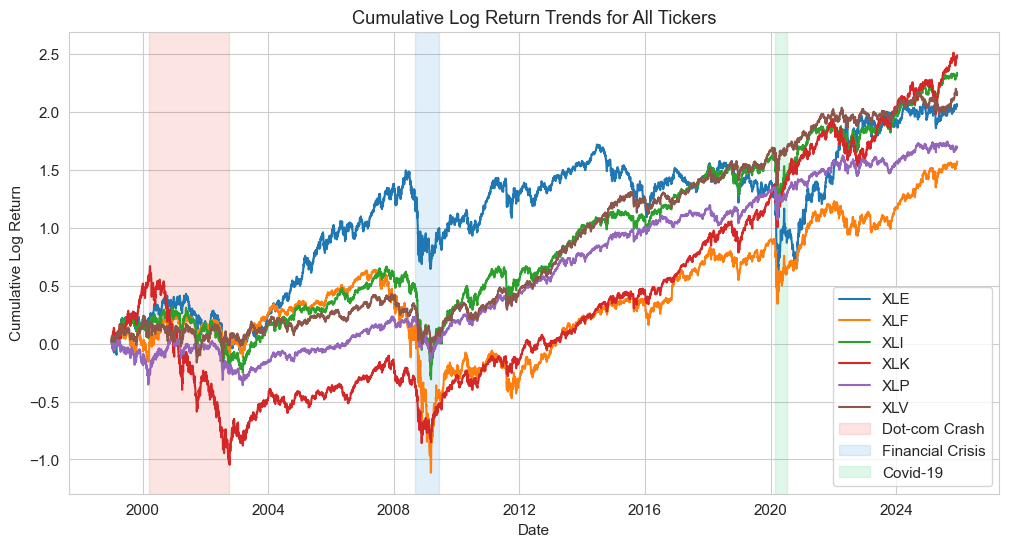

In [6]:
plot_trends(cumulative_log_returns, 'Cumulative Log Return', highlight_crises=True)

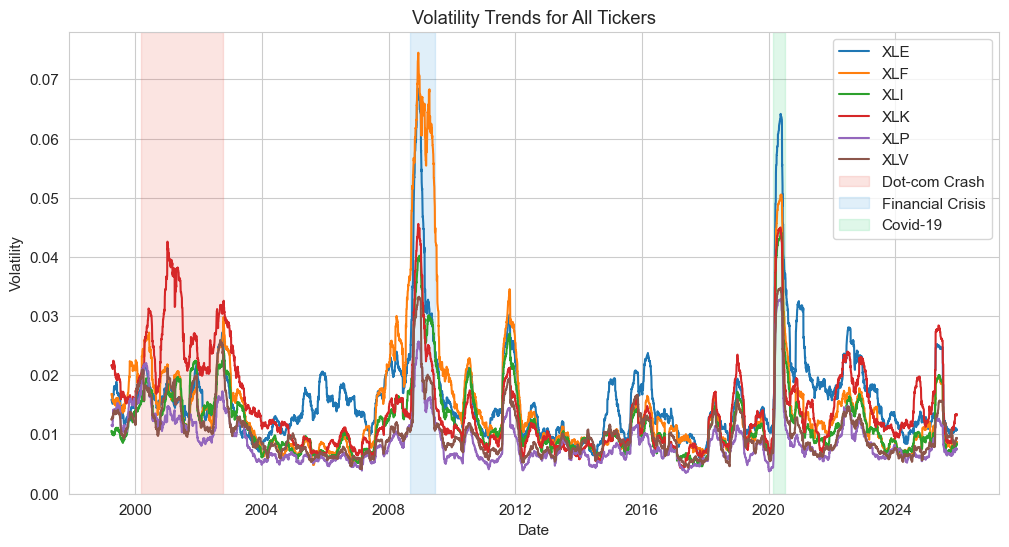

In [7]:
plot_trends(volatility, 'Volatility', highlight_crises=True)

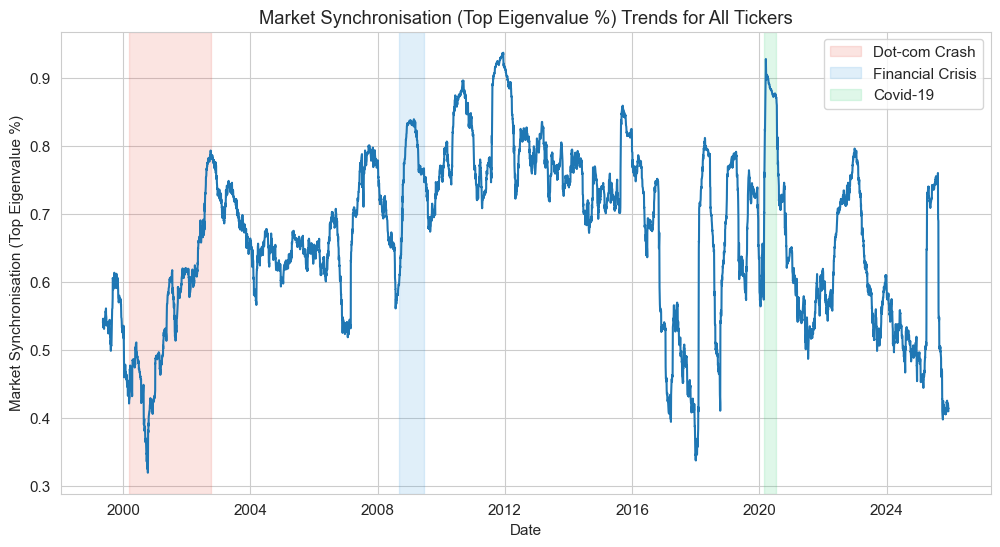

In [8]:
plot_trends(top_eig_proportion, 'Market Synchronisation (Top Eigenvalue %)', highlight_crises=True)

### 1.2.2 Distributions

After applying log transformations to the data, the features shift from having a heavily right-skewed distribution to a normal distribution. The multiple modes/peaks in the log volatility distribution (see Appendices) suggest that a Gaussian Mixtures Model (GMM) is most appropriate for this data.

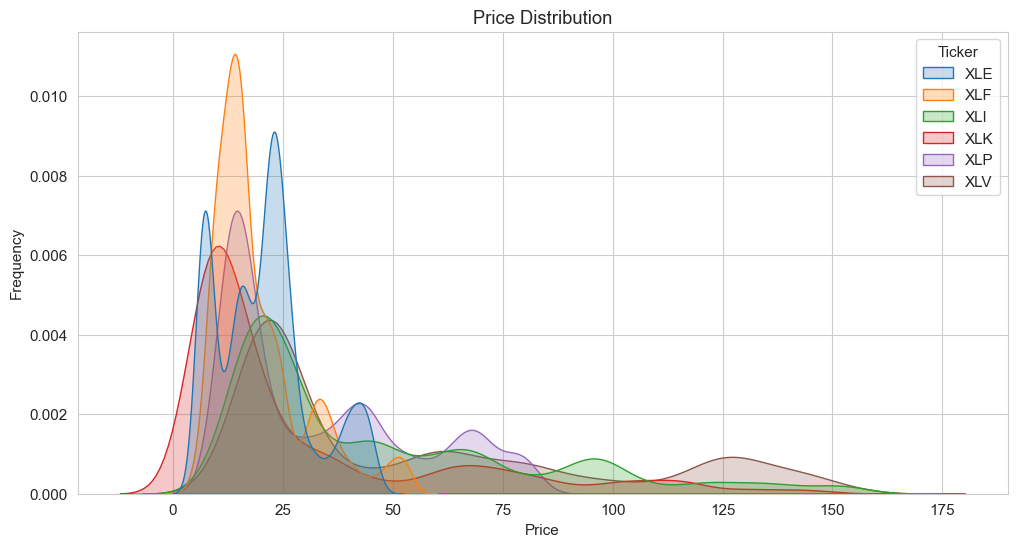

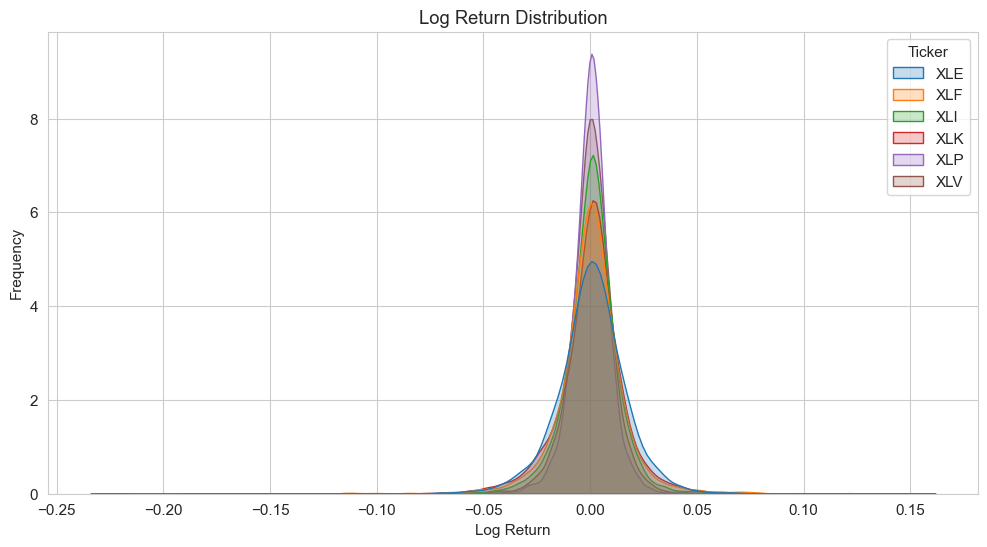

In [9]:
plot_kde(prices, 'Price')
plt.show()
plot_kde(log_returns, 'Log Return')

### 1.2.3 Correlations

The raw price data for XLK and XLF is highly correlated ($R^2=0.9$) but the correlations are largely artificial, driven by price changes over time: 2025 is a distinct cluster in the top right and 2000 is a distinct cluster in the bottom left. 

The log returns still show a positive correlation but it is much weaker ($R^2=0.4$), creating a cloud in the middle. When we zoom in on particular years we can see that sometimes the correlation is very strong (2008) and in others it is very weak (2000).

The effect of the log transformation on the volatility is different: it increases the correlation strength a little by reducing the distance between the most extreme values, creating more of an elliptical shape overall with three or four distinct clusters of volatility.

These variations in correlation structure and volatility are strong evidence of distinct market regimes and suggest GMMs are well-suited to modeling this space.

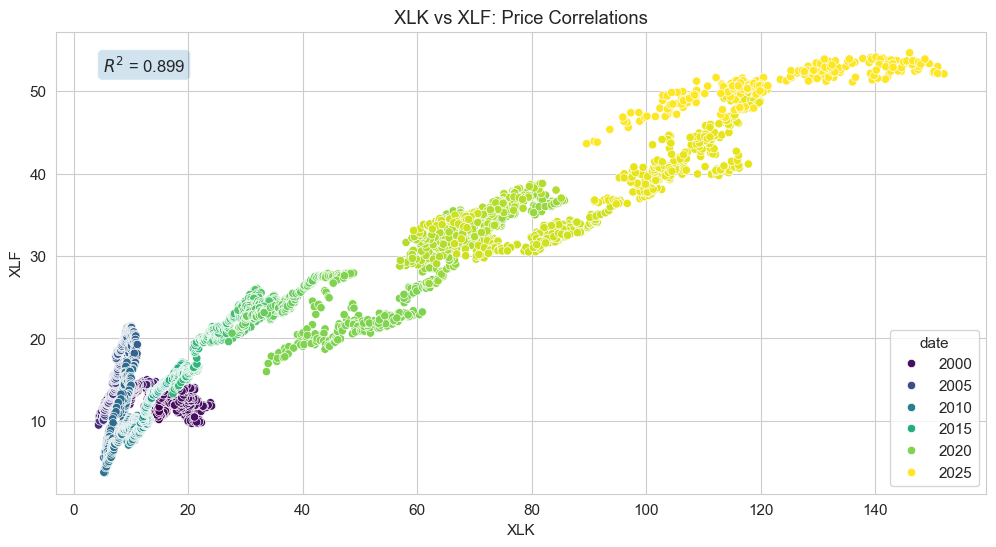

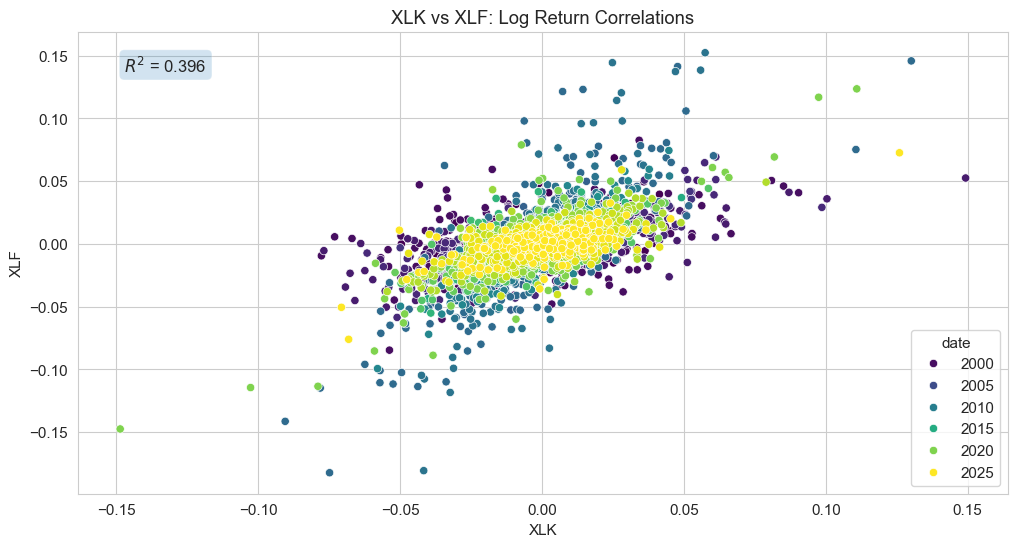

In [ ]:
plot_correlations_over_time(prices, 'Price')
plt.show()
plot_correlations_over_time(log_returns, 'Log Return')

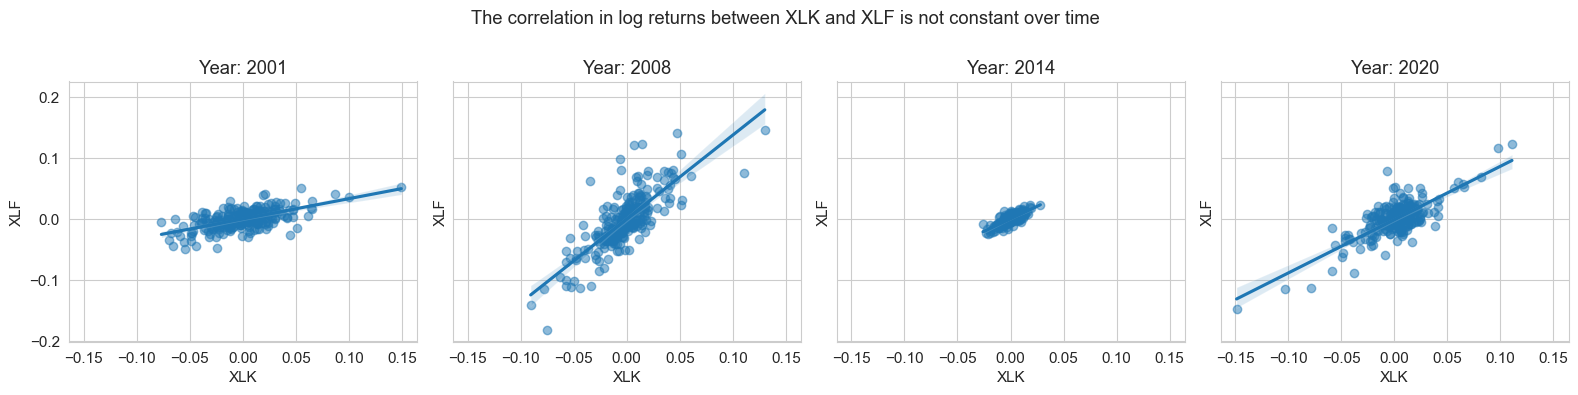

In [11]:
# Plot correlations of XLK and XLF for representative years

key_years = [2001, 2008, 2014, 2020]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)

for ax, year in zip(axes, key_years):
    data = log_returns[log_returns.index.year == year]
    sns.regplot(x='XLK', y='XLF', data=data, scatter_kws={'alpha': 0.5}, ax=ax)
    ax.set_title(f'Year: {year}')
    ax.set_xlabel('XLK')
    ax.set_ylabel('XLF')

plt.tight_layout()
plt.suptitle('The correlation in log returns between XLK and XLF is not constant over time')
plt.subplots_adjust(top=0.8)

### 1.3 Feature Construction

Building on the EDA, three types of of features are created for the final feature set: returns, volatility and market synchronisation. 

We evaluate these on a Gaussian Mixtures Model as it appears to be the best representation of our data with the elliptical clusters dispalyed in the correlations<sup>6</sup>. The key factors we evaluate are:

- Should we use returns, volatility or both?
- Should we log transform them?
- Should we include the market synchronisation indicator?
- Which volatility and/or correlation window is optimal?

The metrics we use to evaluate the model are BIC, AIC and Silhouette Score.<sup>7</sup>

The results clearly indicate that volatility data on its own without the added log transformation and without the market sychronisation factor delivers the most cleanly separated clusters; it has the best BIC, AIC and Silhouette score.

As the volatility window increases from 7 days to 180 days, the BIC gets consistently better. Meanwhile the Silhouette score increases up to 90 days and then declines. 

Both findings challenge our financial intuition which tell us that:
- Including the market synchronisation factor should allow the model to distinguish between periods of market panic and heightened volatility
- Even 90 days is too much of a lag to respond to major market movements: the covid panic took place in less time

This higlights the trade-off between statistical purity and regime usability.

30-60 days is a commonly used timeframe to capture major market changes while being robust to short-term spikes. We chose 30 days to have particularly responsive regimes. 

The market synchronisation factor was included also as it had relatively small negative impact on the model scores, and financial intuition and the EDA above suggests it will be a useful discriminant factor.

In [ ]:
# A flexible feature construction function to evaluate the impact of different feature combinations

def construct_features(
    data=prices,
    vol_window=30,
    corr_window=30,
    volatility_or_returns='Both',
    log_transform=False,
    include_market_sync=True
):
    """
    Construct features for regime detection:
      - Volatility or returns
      - Log transform or not
      - Top eigenvalue proportion ("market synchronicity", optional)
    """
    # Compute basic returns and volatilities
    returns = data.pct_change()
    log_returns = np.log(data / data.shift(1))

    volatility = log_returns.rolling(vol_window).std()
    log_vol = np.log(volatility.replace(0, np.nan))

    # Main features chosen
    if volatility_or_returns == 'Volatility':
        base = log_vol if log_transform else volatility
        feature_frames = [base.copy()]
        for frame in feature_frames:
            frame.columns = frame.columns + '_vol'
    elif volatility_or_returns == 'Returns':
        base = log_returns if log_transform else returns
        feature_frames = [base.copy()]
        for frame in feature_frames:
            frame.columns = frame.columns + '_ret'
    elif volatility_or_returns == 'Both':
        base_vol = log_vol if log_transform else volatility
        base_ret = log_returns if log_transform else returns
        vol_frame = base_vol.copy()
        vol_frame.columns = vol_frame.columns + '_vol'
        ret_frame = base_ret.copy()
        ret_frame.columns = ret_frame.columns + '_ret'
        feature_frames = [vol_frame, ret_frame]

    if include_market_sync:
        sync = eigvals_over_time(log_returns, corr_window).rename('market_sync')
        feature_frames.append(sync)

    features = pd.concat(feature_frames, axis=1, join='inner').dropna()

    return features

construct_features(prices).head()

,XLE_vol,XLF_vol,XLI_vol,XLK_vol,XLP_vol,XLV_vol,XLE_ret,XLF_ret,XLI_ret,XLK_ret,XLP_ret,XLV_ret,market_sync
date,,,,,,,,,,,,,
1999-02-17,0.013983,0.017347,0.011241,0.024437,0.011806,0.014267,-0.009943,0.004016,0.000000,-0.022563,-0.010029,-0.010369,0.600971
1999-02-18,0.014001,0.017360,0.010583,0.024020,0.011897,0.014178,0.002870,0.010000,0.000000,0.005540,0.010727,0.012805,0.599230
1999-02-19,0.012404,0.016349,0.009860,0.023460,0.011661,0.013882,-0.005723,0.003300,0.006382,0.009183,-0.004127,0.002874,0.565752
1999-02-22,0.012636,0.016970,0.010157,0.024323,0.012189,0.014329,0.010072,0.028947,0.015219,0.035487,0.021314,0.021204,0.602201
1999-02-23,0.012599,0.017098,0.010058,0.024420,0.012172,0.014192,-0.008547,0.012788,-0.000625,0.013181,-0.001739,-0.001683,0.599820


In [13]:
# Calculate the key metrics after scaling the data and fitting the GMM

def gmm_pipeline_metrics(data=prices, n_components=3, covariance_type='full', n_init=10, random_state=40466218):
    X_scaled = StandardScaler().fit_transform(data)
    gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, n_init=n_init, random_state=random_state)
    labels = gmm.fit_predict(X_scaled)
    regime_changes = np.sum(labels[1:] != labels[:-1])
    avg_duration = len(labels) / (regime_changes + 1)
    silhouette = silhouette_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)

    return silhouette, bic, aic, avg_duration

In [14]:
# Evaluate the performance of the GMM for different feature combinations: volatility or returns, log transform or not, and market synchronisation or not

feature_metrics = []

for volatility_or_returns in ['Volatility', 'Returns', 'Both']:
    for log_transform in [True, False]:
        for include_market_sync in [True, False]:
            X = construct_features(prices, volatility_or_returns=volatility_or_returns, log_transform=log_transform, include_market_sync=include_market_sync)
            silhouette, bic, aic, avg_duration = gmm_pipeline_metrics(X)
            feature_metrics.append({
                'Volatility or Returns': volatility_or_returns,
                'Log Transform': log_transform,
                'Include Market Sync': include_market_sync,
                'Silhouette': silhouette,
                'BIC': bic,
                'AIC': aic,
                'Avg Duration': avg_duration
            })

feature_metrics_df = pd.DataFrame(feature_metrics)
print("FEATURE EXPERIMENTATION")
print("="*70)
display(feature_metrics_df.round(2))

best_bic = feature_metrics_df.loc[feature_metrics_df['BIC'].idxmin()]
print(f"\n✓ Best BIC: Volatility or Returns={best_bic['Volatility or Returns']}, Log Transform={best_bic['Log Transform']}, Include Market Sync={best_bic['Include Market Sync']} (BIC={best_bic['BIC']:.3f})")


FEATURE EXPERIMENTATION


,Volatility or Returns,Log Transform,Include Market Sync,Silhouette,BIC,AIC,Avg Duration
0,Volatility,True,True,0.14,77100.23,76370.81,28.96
1,Volatility,True,False,0.24,61673.47,61107.66,43.54
2,Volatility,False,True,0.38,55860.48,55131.06,78.47
3,Volatility,False,False,0.44,39129.15,38563.34,74.98
4,Returns,True,True,0.25,98089.80,97360.38,3.66
5,Returns,True,False,0.17,78387.69,77821.52,3.14
6,Returns,False,True,0.12,97217.15,96487.73,3.09
7,Returns,False,False,0.15,78450.66,77884.50,3.02
8,Both,True,True,0.22,153754.85,151614.31,7.98
9,Both,True,False,0.23,139078.66,137224.44,7.72



✓ Best BIC: Volatility or Returns=Volatility, Log Transform=False, Include Market Sync=False (BIC=39129.154)


In [15]:
# Evaluate the sensitivity of the volatility window

vol_windows = [7, 30, 60, 90, 120, 150, 180]

window_results = []

for vw in vol_windows:
    X = construct_features(prices, vol_window=vw, volatility_or_returns='Volatility', log_transform=False, include_market_sync=True)
    silhouette, bic, aic, avg_duration = gmm_pipeline_metrics(X)
    window_results.append({
        'Vol Window': vw,
        'Silhouette': silhouette,
        'BIC': bic,
        'AIC': aic,
        'Avg Duration': avg_duration
    })

window_df = pd.DataFrame(window_results)
print("WINDOW PARAMETER SENSITIVITY ANALYSIS")
print("="*70)
display(window_df.round(2))

WINDOW PARAMETER SENSITIVITY ANALYSIS


,Vol Window,Silhouette,BIC,AIC,Avg Duration
0,7,0.28,73091.78,72362.36,12.34
1,30,0.38,55860.48,55131.06,78.47
2,60,0.38,48642.69,47913.74,129.19
3,90,0.40,45887.09,45158.63,167.20
4,120,0.38,43133.62,42405.64,151.32
5,150,0.35,40712.82,39985.32,207.12
6,180,0.35,37959.50,37232.49,347.26


### 1.4 Final Feature Selection

In [17]:
# Create final feature set based on the above analysis

X_final = construct_features(prices, vol_window=30, volatility_or_returns='Volatility', log_transform=False, include_market_sync=True)
X_final_scaled = StandardScaler().fit_transform(X_final)

In [18]:
X_final

,XLE_vol,XLF_vol,XLI_vol,XLK_vol,XLP_vol,XLV_vol,market_sync
date,,,,,,,
1999-02-17,0.013983,0.017347,0.011241,0.024437,0.011806,0.014267,0.600971
1999-02-18,0.014001,0.017360,0.010583,0.024020,0.011897,0.014178,0.599230
1999-02-19,0.012404,0.016349,0.009860,0.023460,0.011661,0.013882,0.565752
1999-02-22,0.012636,0.016970,0.010157,0.024323,0.012189,0.014329,0.602201
1999-02-23,0.012599,0.017098,0.010058,0.024420,0.012172,0.014192,0.599820
...,...,...,...,...,...,...,...
2025-12-05,0.010416,0.008470,0.007876,0.014356,0.008334,0.009001,0.435465
2025-12-08,0.010446,0.008287,0.007878,0.014134,0.008444,0.009336,0.444881
2025-12-09,0.010486,0.008284,0.007907,0.013726,0.008451,0.009544,0.438794


In [19]:
print('Mean values per feature of original data:')
print(X_final.mean(axis=0))
print('Mean values per feature of scaled data:')
print(X_final_scaled.mean(axis=0))

Mean values per feature of original data:
XLE_vol        0.015927
XLF_vol        0.014441
XLI_vol        0.011735
XLK_vol        0.014158
XLP_vol        0.008571
XLV_vol        0.010073
market_sync    0.659532
dtype: float64
Mean values per feature of scaled data:
[-1.60051120e-16 -1.17932404e-16 -4.21187158e-16  3.36949727e-17
  1.68474863e-16  5.05424590e-16  7.07594426e-16]


## 2. Regime Detection

### 2.1 Clustering Method

The final features used in the model were therefore:

- 30-day rolling volatility 
- Market synchronisation (the first eigenvalue)

All data was standardised to minimise the impact of varying scales: in particular the difference in magnitudes between the market synchronisation (mean = 0.65) and the volatility scores (mean = 0.01). Standardisation was used instead of normalisation to retain the relative value of the outliers because the outliers are a critical indicator of distinct market regimes (market panics).

Only the first eigenvalue was used as it is determined to be disproportionately influential and a significant market signal in itself, while most others are determined to be "noise". The number of features was kept intentionally small as this GMMs are particularly susceptible to the curse of dimensionality.

Based on the shape of the data illustrated in the correlation and distribution sections of the EDA, we can see that different time periods have significiantly different variance and correlation structures and the strict structure of K-Means is poorly suited to model the data. 

This aligns with the literature which suggests that GMM is superior to K-Means for financial regime detection because:

1. GMM allows elliptical clusters (different variance per regime) <sup>6</sup>
2. Financial regimes have heteroskedasticity (Crisis is more variable) <sup>4</sup>
3. GMM provides soft assignments (probability of each regime)<sup>6</sup>

The full covariance type fits our data best which provides supporting evidence for points 1 and 2 above, and fits what we saw in the EDA.

There is no clear "elbow" point in our BIC and Silhouette plots looking at different cluster sizes, which is a well-known feature with financial time series data. However, the drop-off in Silhouette score between 2 and 3 clusters is significantly smaller than the rest, and 3 clusters are a reasonable description of market regimes (Stable, Correction and Panic). Thus it is the best balance between empirical data and financial intuition.

In [20]:
cov_results = []
for cov in ['spherical', 'diag', 'full']:
    silhouette, bic, aic, avg_duration = gmm_pipeline_metrics(X_final_scaled, n_components=3, covariance_type=cov)
    cov_results.append({
        'Covariance': cov.capitalize(),
        'BIC': bic,
        'AIC': aic,
        'Silhouette': silhouette,
        'Avg Duration': avg_duration
    })

cov_df = pd.DataFrame(cov_results)
print("COVARIANCE TYPE COMPARISON (k=3)")
print("="*70)
display(cov_df.round(2))

COVARIANCE TYPE COMPARISON (k=3)


,Covariance,BIC,AIC,Silhouette,Avg Duration
0,Spherical,90608.37,90431.13,0.33,40.65
1,Diag,74259.91,73959.96,0.28,42.18
2,Full,55860.48,55131.06,0.38,78.47


In [21]:
cluster_size_results = []
for k in range(2, 7):
    silhouette, bic, aic, avg_duration = gmm_pipeline_metrics(X_final_scaled, n_components=k, covariance_type='full')
    cluster_size_results.append({
        'k': k,
        'BIC': bic,
        'AIC': aic,
        'Silhouette': silhouette,
        'Avg Duration': avg_duration
    })
    
cluster_size_df = pd.DataFrame(cluster_size_results)
print("CLUSTER SIZE SUMMARY")
print("="*70)
display(cluster_size_df.round(2))


CLUSTER SIZE SUMMARY


,k,BIC,AIC,Silhouette,Avg Duration
0,2,58922.19,58438.18,0.42,76.68
1,3,55860.48,55131.06,0.38,78.47
2,4,52558.69,51583.86,0.29,48.20
3,5,48657.39,47437.15,0.16,37.49
4,6,46725.89,45260.24,0.15,32.76


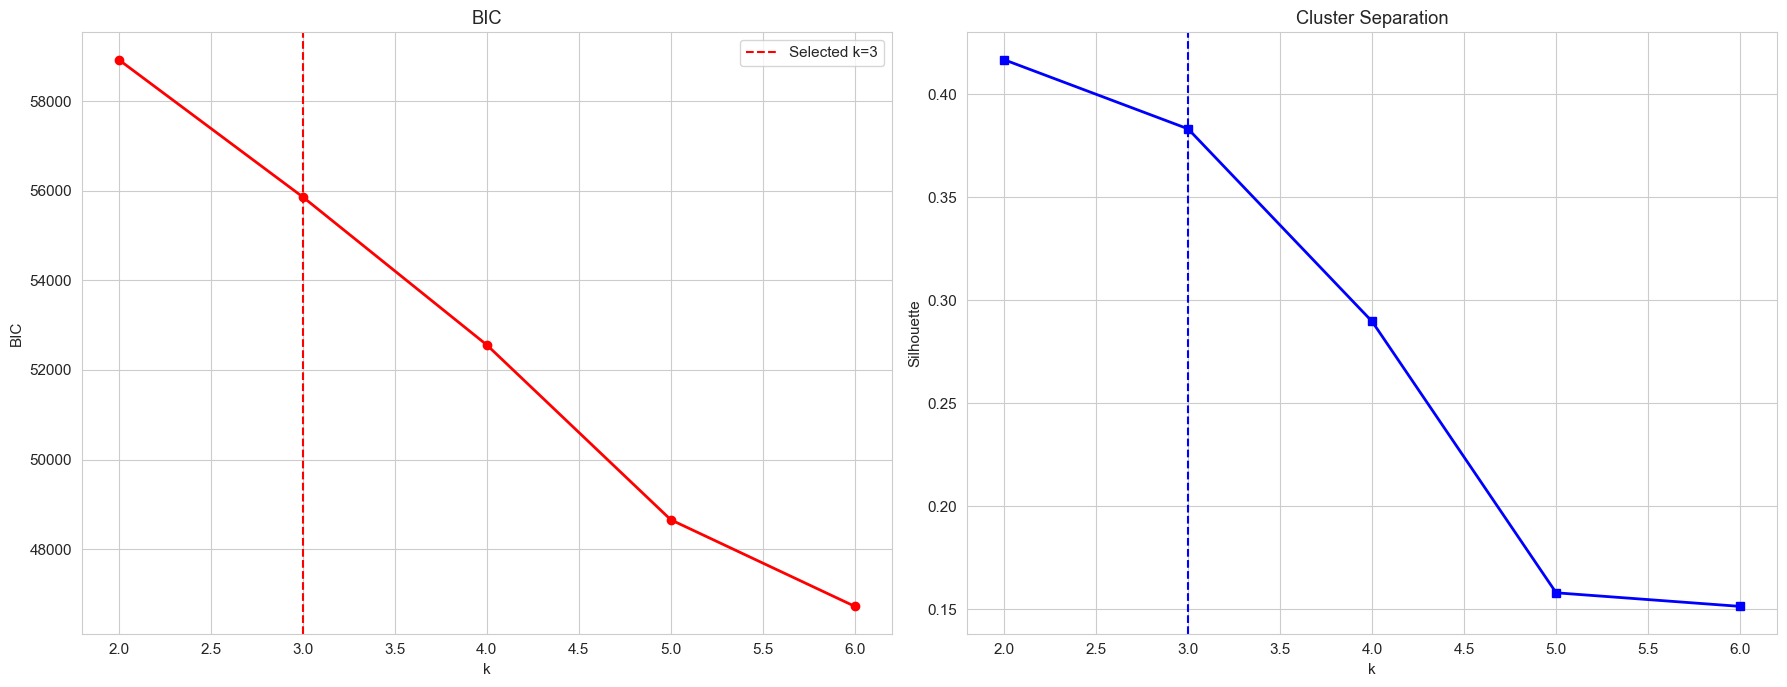

In [ ]:
# Plot the BIC and Silhouette plots for different cluster sizes to determine the optimal number of clusters

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# BIC plot
ax = axes[0]
ax.plot(cluster_size_df['k'], cluster_size_df['BIC'], 'o-', color='red', linewidth=2)
ax.axvline(3, color='red', linestyle='--', label='Selected k=3')
ax.set(xlabel='k', ylabel='BIC', title='BIC')
ax.legend()

# Silhouette plot
ax = axes[1]
ax.plot(cluster_size_df['k'], cluster_size_df['Silhouette'], 's-', color='blue', linewidth=2)
ax.axvline(3, color='blue', linestyle='--')
ax.set(xlabel='k', ylabel='Silhouette', title='Cluster Separation')

plt.tight_layout();

### 2.2 Cluster Intepretation

We had two goals for our regime detection based on financial intuition:

- Use the market volatility and market synchronisation signals to accurately identify known historical moments (dot-com crash, 2008 financial crisis and covid)
- Identify the moments in between when volatility returns to a relative calm but market synchronisation shows distinct patterns

This enforces a certain structure on the regimes we detect: 2 clusters is too few, 4 clusters is likely the maximum. 

A 2-regime detection of Bull / Bust is a reasonable description of the market, but it is helpful to distinguish between a market-wide panic (covid) and a sector-specific correction (dot-com crash). It is also helpful to distinguish between the sharp spike in volatility during a panic and the overall period of heightened volatility that that tends to form either side of a panic and is a bit more durable.

The optimal number of clustered identified was k=3 which fit a structure: Stable, Correction and Panic. 

- The panic periods are sharp spikes in volatility that exclusively describe the 2008 financial crisis and 2020 covid crisis. 
- The model distinguishes these two crises from the dot-com crash because the overall level of volatility was much lower (nearly half the size) and stayed elevated much longer (years vs. months). 
- The majority of the market falls into the Stable cluster: periods of lower volatility with steady growth in returns.

The clearest illustration of the difference between these three regimes is in the Sharpe Ratio: a measure of risk-adjusted returns. 

- During a market panic the ratio is negative: -0.27. 
- During the market correction the ratio is 0.31.
- During the stable period the ratio is more than doubled to 0.75.

This illustrates that the regimes are not only substantially different, but they're different in a way that matters: financial performance.

In [23]:
# Fit the model and apply labels

def fit_gmm(X, k=3, covariance_type='full', series_index = X_final.index):
    """Fit GMM and return model + labels + probabilities."""
    gmm = GaussianMixture(
        n_components=k, 
        covariance_type=covariance_type, 
        n_init=10, 
        random_state=40466218
    )
    X_scaled = StandardScaler().fit_transform(X)
    labels = gmm.fit_predict(X_scaled)
    probs = gmm.predict_proba(X_scaled)
    regime_series = pd.Series(labels, index=series_index, name='regime')
    return gmm, labels, probs, regime_series

def regime_labelling(regime_series, regime_names):
    regime_labels_df = pd.DataFrame({'cluster_num': regime_series})
    regime_labels_df['regime'] = regime_labels_df['cluster_num'].map(dict(enumerate(regime_names)))
    return regime_labels_df

# Calculate financial metrics to go beyond the standard clustering metrics

def calculate_risk_return_by_regime(returns, regime_series, regime_names):
    """Calculate annualized risk/return metrics per regime."""
    k = regime_series.nunique()
    results = []
    
    for ticker in returns.columns:
        aligned = regime_series.reindex(returns.index).ffill().dropna()
        ticker_rets = returns.loc[aligned.index, ticker]
        
        for regime in range(k):
            mask = aligned == regime
            regime_rets = ticker_rets[mask]
            ann_ret = regime_rets.mean() * 252
            ann_vol = regime_rets.std() * np.sqrt(252)
            results.append({
                'Ticker': ticker,
                'Regime': regime,
                'Ann Return': ann_ret,
                'Ann Vol': ann_vol,
                'Sharpe': ann_ret / ann_vol if ann_vol > 0 else 0
            })
    
    results = pd.DataFrame(results)
    results['Regime'] = results['Regime'].map(dict(enumerate(regime_names)))

    return results

def summarize_by_regime(risk_return_df):
    """Aggregate risk/return metrics across tickers."""
    return risk_return_df.groupby('Regime').agg({
        'Ann Return': 'mean', 
        'Ann Vol': 'mean', 
        'Sharpe': 'mean'
    })

# Plot the overall market volatility coloured by regimes in the background

def plot_regime_volatility(regime_labels_df):
    fig, ax = plt.subplots(figsize=(14, 6))

    # Ensure regime labels are aligned with market_volatility index
    regimes = regime_labels_df.reindex(market_volatility.index).ffill()

    ax.plot(market_volatility.index, market_volatility, color='black', lw=1, label='Volatility')
    
    # Use colors for regime labels
    label_palette = {
        'Panic': '#3498db',
        'Correction': '#ff7043',
        'Stable': '#2ecc71',
    }
    trans = ax.get_xaxis_transform()

    for label, color in label_palette.items():
        ax.fill_between(market_volatility.index, 0, 1, 
                        where=(regimes['regime'] == label) if 'regime' in regimes.columns else (regimes == label),
                        color=color, alpha=0.3, 
                        transform=trans, label=label)

    ax.set_title(f'Detected Regimes - Market Volatility', fontsize=14)
    ax.axhline(y=market_volatility.mean(), color='gray', linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')
    plt.tight_layout();

In [24]:
# Fit the final model and apply labels
best_k = 3
gmm, labels, probs, regime_series = fit_gmm(X_final_scaled, best_k)

regime_names = ['Correction', 'Stable', 'Panic']

regime_labels_df = regime_labelling(regime_series, regime_names)
regime_labels_df.value_counts()

cluster_num  regime    
1            Stable        4684
0            Correction    1949
2            Panic          115
Name: count, dtype: int64

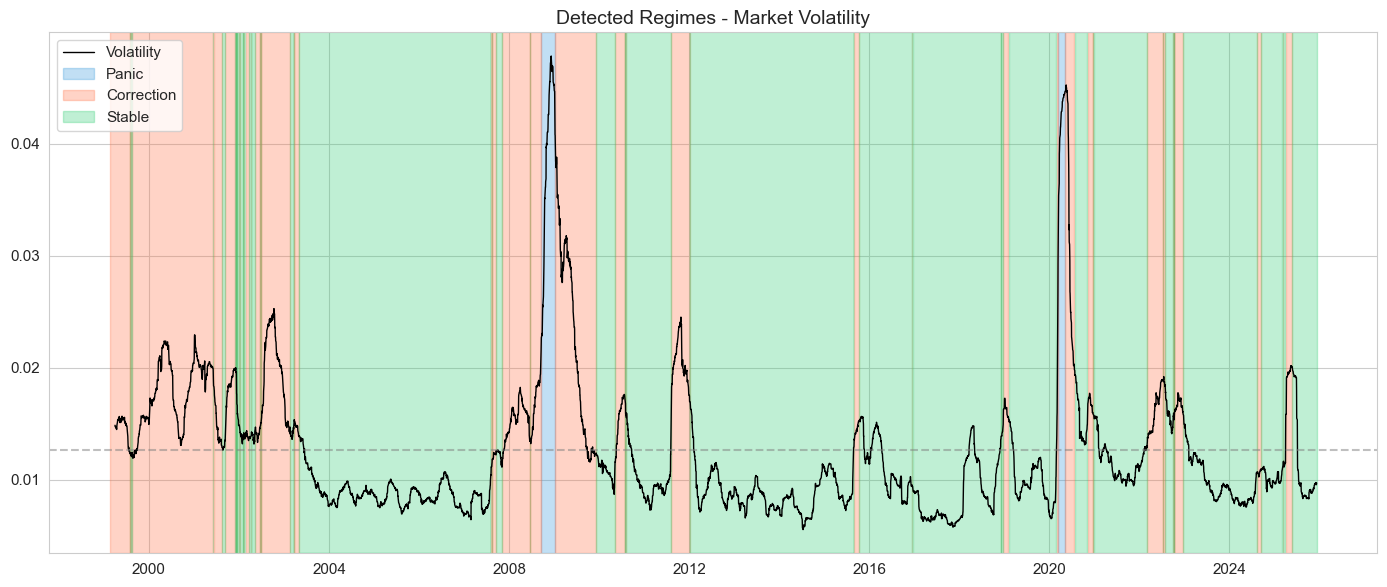

In [ ]:
# Display the overall market volatility coloured by regimes in the background

plot_regime_volatility(regime_labels_df);

In [26]:
# Calculate risk/return metrics by regime
risk_return_df = calculate_risk_return_by_regime(returns, regime_series, regime_names)
summary = summarize_by_regime(risk_return_df)
print("ECONOMIC VALIDATION: Risk/Return by Regime")
print("="*50)
summary

ECONOMIC VALIDATION: Risk/Return by Regime


,Ann Return,Ann Vol,Sharpe
Regime,,,
Correction,0.089506,0.300678,0.309524
Panic,-0.180923,0.710380,-0.278189
Stable,0.117213,0.158578,0.749919


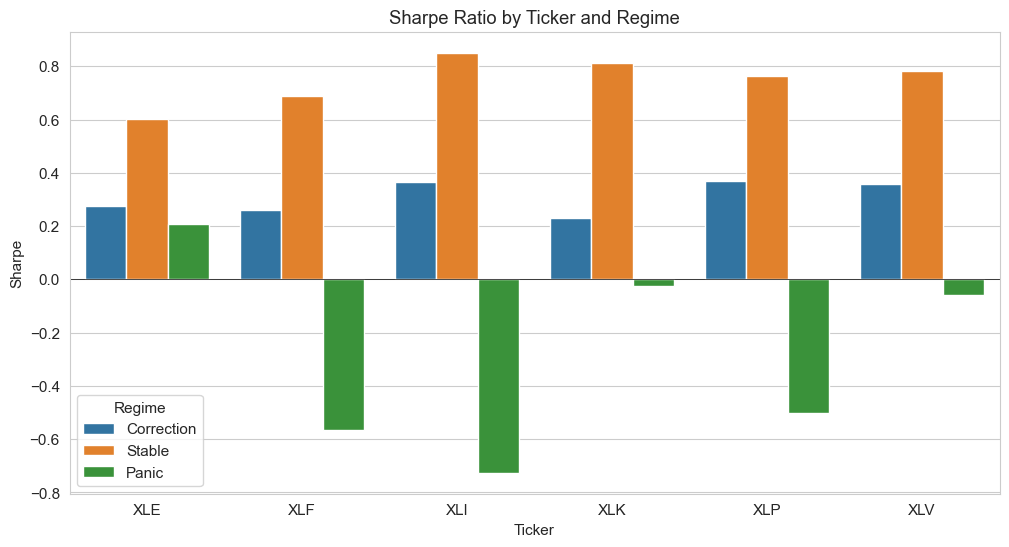

In [27]:
# Plot the Sharpe Ratio by Ticker and Regime

pivot = risk_return_df.pivot(index='Ticker', columns='Regime', values='Sharpe')
sns.barplot(data=risk_return_df, x='Ticker', y='Sharpe', hue='Regime');
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Sharpe Ratio by Ticker and Regime');

## 3. Integration with Prediction

One-hot encoding was used to integrate the regimes into the model as three separate binary variables: `regime_0` (Correction), `regime_1` (Panic) and `regime2` (Stable). These three features are added to the original feature matrix of 15 features (displayed below).

If we were using a simpler model like OLS then we would model these as feature interactions: e.g. `regime_0_vol_90 = regime_0 * vol_30` to capture the idea that volatility has a different effect in different regimes. However as we are using a tree-based model with `LightGBM`, the model will handle this automatically by splitting the tree at `regime_0` and then `vol_30` in the next branch. 

The model with regimes included in the `StudentExt` were compared against the original `Student` class using a rigorous walk-forward validation approach using `mltester` with the parameters `s=50`, `h=10`. From this expanding window evaluation we calculated three key metrics: `Directional Accuracy`, `MAE` and `RMSE`. Both classes were assessed on identical parameters for consistent evaluation.

The results were as follows:

Measure | Student | StudentExt | Diff  |
------- | ------- | ---------- | ----- |
DirAcc  | 0.5071  |  0.5110    | +0.04 | 
MAE     | 0.0303  |  0.0303    | +/- 0 | 
RMSE    | 0.0430  |  0.0430    | +/- 0 | 

In other words the models performed almost identically with the addition of regimes. 

This raises the question: why did the results in the previous section show financial gains from the regime classification if it holds so little predictive power? 

An important clarification is that it provided limited *incremental* predictive power. The `Student` class already contains 15 features and two of the top 5 features are `vol_30` and `bbands_lower`: the model already applies a significant weight to the rolling window volatility that plays such a dominant role in the regime detection. It therefore appears the regimes are providing little new information.

Whereas in the Sharpe Ratio calculations above the regimes are providing the only information we have to discriminate returns: if it was one of many interacting features it would likely have a smaller impact on the Sharpe Ratio too. It is also important to recognise that classifiying the past is a comparatively simpler task to predicting the future. 

In [28]:
# Demonstration of StudentExt internals
from student_ext import StudentExt

ticker = 'XLK'
demo_data = ohlcv[ohlcv['Ticker'] == ticker]
demo_data['date'] = pd.to_datetime(demo_data['Date'])
demo_data = demo_data.set_index('date').sort_index().iloc[:500]
demo_y = demo_data['Close'].shift(-1)

# Create a StudentExt instance
demo_model = StudentExt(n_regimes=3)
demo_model.fit(demo_data, demo_y)

features = demo_model._make_features(demo_data)

# Display the regimes added to the original features
features

,open,high,low,close,volume,vol_30,sma_dist_50,sma_dist_200,macdsignal,adx,bbands_upper,bbands_lower,natr,obv,ad,regime_0,regime_1,regime_2
date,,,,,,,,,,,,,,,,,,
1999-10-18,14.835999,14.911783,14.352153,14.736898,3011800.0,0.014368,-0.049860,0.028479,-0.019263,18.609237,16.215676,14.824492,2.699504,5232200.0,-3.390321e+05,0,1,0
1999-10-19,14.900114,14.923432,14.427928,14.503711,2947800.0,0.014545,-0.064760,0.011431,-0.053442,20.380089,16.259293,14.646214,2.791013,2284400.0,-2.385152e+06,0,1,0
1999-10-20,14.876801,15.092491,14.760211,15.086661,796800.0,0.016424,-0.028069,0.051182,-0.080566,21.431910,16.209735,14.616490,2.770274,3081200.0,-1.616310e+06,0,1,0
1999-10-21,14.596989,14.865144,14.503717,14.841826,1361800.0,0.016503,-0.043856,0.033460,-0.105566,22.808891,16.224102,14.556654,2.895383,1719400.0,-4.302261e+05,0,1,0
1999-10-22,15.016714,15.086667,14.870977,14.876806,399400.0,0.016342,-0.041891,0.035204,-0.127128,23.340269,16.230827,14.504460,2.799805,2118800.0,-8.080369e+05,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2000-12-18,13.198173,13.268128,12.545260,12.685170,1456000.0,0.034608,-0.152225,-0.323914,-0.510601,26.480466,14.892261,12.635026,5.622029,-36766600.0,-9.771573e+06,1,0,0
2000-12-19,12.708490,13.238982,12.253783,12.312078,1598400.0,0.034795,-0.172550,-0.342237,-0.525576,26.915648,14.925764,12.400985,5.950214,-38365000.0,-1.118081e+07,1,0,0
2000-12-20,11.635844,11.869027,11.239433,11.391002,4089800.0,0.036740,-0.229684,-0.389782,-0.560930,28.154562,15.072956,11.954152,6.644582,-42454800.0,-1.330145e+07,1,0,0


In [29]:
summary = pd.DataFrame({
    'Parameter': ['Vol Window', 'Corr Window', 'k', 'Algorithm', 'Covariance', 'Silhouette', 'BIC'],
    'Value': [f'30d', f'30d', 3, 'GMM', 'Full', 
              f"{silhouette_score(X_final_scaled, labels):.3f}", f"{gmm.bic(X_final_scaled):.0f}"]
})
print("FINAL MODEL SUMMARY")
print("="*40)
display(summary)

FINAL MODEL SUMMARY


,Parameter,Value
0,Vol Window,30d
1,Corr Window,30d
2,k,3
3,Algorithm,GMM
4,Covariance,Full
5,Silhouette,0.383
6,BIC,55860


In [30]:
# Original Student Class

tickers = prices.columns

run_mltester(
    model_spec="student:Student",
    tickers=tickers,
    data_file="data/prices.csv",
    horizon=10,
    step=50,
    out_dir="outputs",
)

   XLE: DirAcc=0.4937  MAE=0.038714  RMSE=0.054789
   XLF: DirAcc=0.4794  MAE=0.035119  RMSE=0.053539
   XLI: DirAcc=0.5325  MAE=0.028873  RMSE=0.040872
   XLK: DirAcc=0.4901  MAE=0.035099  RMSE=0.047750
   XLP: DirAcc=0.5336  MAE=0.019755  RMSE=0.027306
   XLV: DirAcc=0.5142  MAE=0.024506  RMSE=0.033671
Saved outputs to /Users/cobro/Documents/University/Assignments/Machine Learning/Submission/2/outputs


,ticker,diracc,mae,rmse
0,XLE,0.493675,0.038714,0.054789
1,XLF,0.479387,0.035119,0.053539
2,XLI,0.532520,0.028873,0.040872
3,XLK,0.490103,0.035099,0.047750
4,XLP,0.533562,0.019755,0.027306
5,XLV,0.514213,0.024506,0.033671
6,MEAN,0.507243,0.030344,0.042988


In [31]:
# Extended Student Class with Regimes

run_mltester(
    model_spec="student_ext:StudentExt",
    tickers=tickers,
    data_file="data/prices.csv",
    horizon=10,
    step=50,
    out_dir="outputs_ext",
)

# note running python student_ext.py will present identical results: the parameters are identical

   XLE: DirAcc=0.4992  MAE=0.038701  RMSE=0.054771
   XLF: DirAcc=0.4788  MAE=0.035122  RMSE=0.053530
   XLI: DirAcc=0.5330  MAE=0.028810  RMSE=0.040777
   XLK: DirAcc=0.4888  MAE=0.035163  RMSE=0.047848
   XLP: DirAcc=0.5388  MAE=0.019752  RMSE=0.027331
   XLV: DirAcc=0.5276  MAE=0.024468  RMSE=0.033821
Saved outputs to /Users/cobro/Documents/University/Assignments/Machine Learning/Submission/2/outputs_ext


,ticker,diracc,mae,rmse
0,XLE,0.499181,0.038701,0.054771
1,XLF,0.478791,0.035122,0.053530
2,XLI,0.532966,0.028810,0.040777
3,XLK,0.488763,0.035163,0.047848
4,XLP,0.538771,0.019752,0.027331
5,XLV,0.527608,0.024468,0.033821
6,MEAN,0.511014,0.030336,0.043013


## 4. Baseline Comparison

The regime detection method used above was compared with Hallac et. al's Greedy Gaussian Segmentation (GGS) method for external validation.<sup>3</sup> 

In the report *Greedy Gaussian segmentation of multivariate time series* they show on page 743 the cumulative returns of three indicies: MSCI World, S&P GSCI Crude Oil, and J.P. Morgan Global Government Bonds. The results are available on their [Github repo](https://github.com/cvxgrp/GGS/blob/master/Data/ReturnsandDates.txt).

Using their raw log returns data I replicate their cumulative returns plot as the baseline for a comparson. I then implement the same procedure used above for my regime detection above:

- Engineer new features (rolling volatility per ticker and market synchronisation)
- Standardise the data with
- Fit a GMM with k=3 

The results show that GGS produces much more stable regimes with cleaner breaks in time, but it doesn't identify specific market regimes (just 10 unique segments) and it is less responsive to market changes. The optimal choice between GGS and GMMs depends on what the goal is: stability and clean time segments or responsiveness and defined recurring market regimes?

Using the same volatility window of 30 days on Hallac et. al's data produces notably noisier results than on my 5 tickers, with regular regime switching back-and-forth between Regime 0 and Regime 2. Using a volatility window of 90 days smooths that out and identifies similar key breakpoints to Hallac et. al: the uninterrupted period of steady growth between 2004 and 2008 (Regime 2), the sharp spike in the 2008 financial crisis (Regime 0) and the sharp drop in oil prices in 2009 (Regime 1). 

The smoothed out 90-day volatility window is a closer comparison to the GGS method because it's a closer reflection of what GGS aims to do. 

Rather than trying to identify clusters, GGS tries to identify breakpoints. Breakpoints are the specific point in time when a regime switches. This has an inherent strength of maintaining time-continuity, so it doesn't rapidly switch back and forth between regimes. However it comes with a limitation, it assumes each individual segment is unique. 

Hidden Markov Models (HMMs) provide a similar level of time-continuity but assume the market cycles through a set of market states. This allows HMMs to identify specific regimes that repeat over these periods, whereas GGS simply identifies the distinct breakpoints but provides no indication about which "regime" the market is in at any given time: it assumes all 10 market segments are unique.

By defining clusters using GMMs we have identified recurring regimes with distinct characteristics: that is what allowed us to easily identify significant differences in the Sharpe Ratio. It didn't require any additional analysis, while GGS would require an extra layer of clustering to group the segments together.

In [32]:
# Taken from https://github.com/cvxgrp/GGS/blob/master/Data/ReturnsandDates.txt
hallac_returns = pd.read_csv("data/hallac_returns_and_dates.txt", sep = " ", header = None)

# Indices used in paper and specified here: https://github.com/cvxgrp/GGS/blob/master/financeExample.py
hallac_key_indices = hallac_returns.iloc[:, [0, 1, 4, 8]]
hallac_key_indices.columns = ["Date", "DM Stocks", "Oil", "GVT Bonds"]

hallac_data = hallac_key_indices.copy()
hallac_data['Date'] = pd.to_datetime(hallac_data['Date'])
hallac_data = hallac_data.set_index('Date')
hallac_data.head()

,DM Stocks,Oil,GVT Bonds
Date,,,
1997-01-02,-0.007709,-0.008627,-0.004780
1997-01-03,0.006614,-0.003758,0.001222
1997-01-06,0.002515,0.030447,-0.000832
1997-01-07,0.001422,-0.005182,-0.000015
1997-01-08,-0.004571,0.014898,0.001453


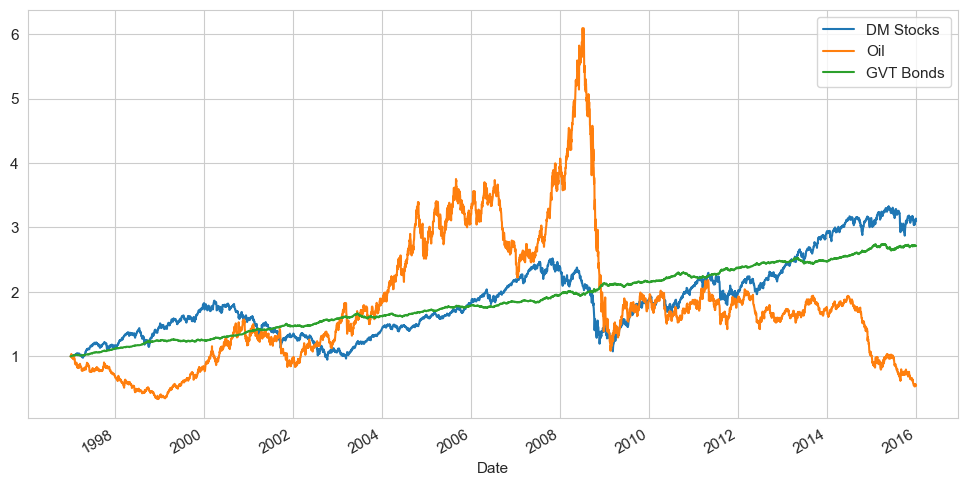

In [33]:
# Hallac visualises the breakpoints in the paper against the cumulative returns of the tickers - this recreates it

cumulative_returns_df = pd.DataFrame({
    ticker: np.exp(hallac_data[ticker].cumsum())
    for ticker in hallac_data.columns
}, index=hallac_data.index)

cumulative_returns_df.plot();

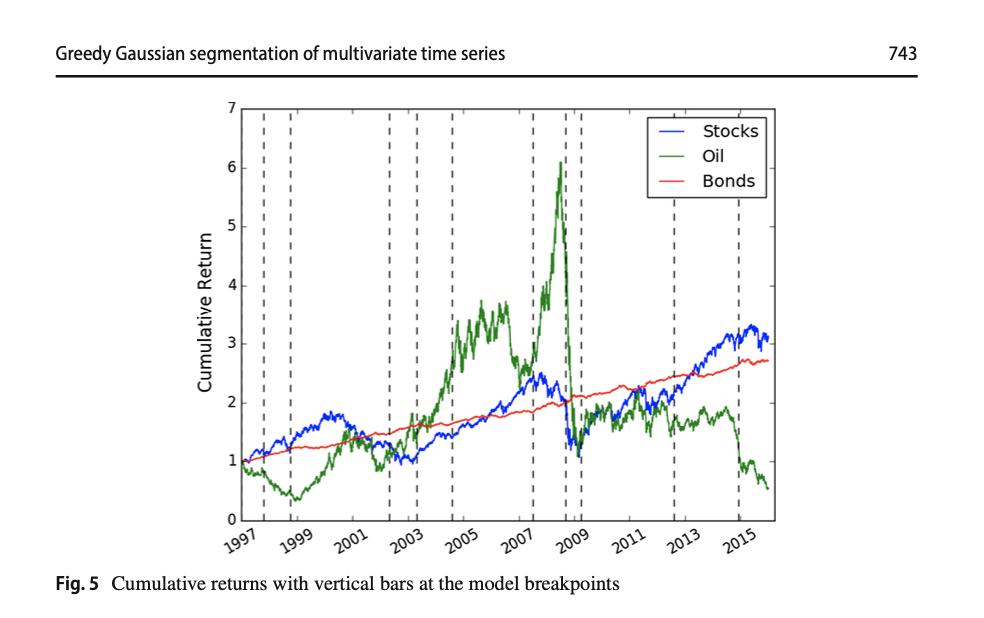

In [34]:
# Image taken directly from the paper

from IPython.display import Image
Image(filename='hallac_3tickers_10breakpoints.png')

In [35]:
 # Hallac data is already log returns so applying a slimmed down version of the construct_features function

def construct_features_simplified(data=hallac_data, vol_window=30):
    volatility = data.rolling(vol_window).std()
    base = volatility
    feature_frames = [base.copy()]
    for frame in feature_frames:
        frame.columns = frame.columns + '_vol'
    
    sync = eigvals_over_time(hallac_data, 30).rename('market_sync')
    feature_frames.append(sync)

    hallac_features = pd.concat(feature_frames, axis=1, join='inner').dropna()
    return hallac_features

def run_hallac_gmm_model(vol_window=30, best_k=3, regime_names=None):
    """
    Constructs features using a simplified method, scales them,
    fits a GMM, labels regimes, and returns the labelled DataFrame.
    """
    if regime_names is None:
        regime_names = [f'Regime {i}' for i in range(best_k)]
    hallac_features = construct_features_simplified(vol_window=vol_window)
    hallac_features_scaled = StandardScaler().fit_transform(hallac_features.dropna())
    gmm, labels, probs, regime_series = fit_gmm(
        hallac_features_scaled, best_k, series_index=hallac_features.index
    )
    hallac_regime_labels_df = regime_labelling(regime_series, regime_names)
    return hallac_regime_labels_df

def plot_hallac_regimes(hallac_regime_labels_df, hallac_data, vol_window=30):
    tickers_to_show = hallac_data.columns[:3] 

    fig, ax = plt.subplots(figsize=(14, 6))

    # Align regime labels
    hallac_regimes = hallac_regime_labels_df.reindex(hallac_data.index).ffill()

    # Colors for 10 regimes (showing example colors, feel free to adjust or use a palette)
    label_palette = {
        'Regime 0': '#1f77b4',
        'Regime 1': '#ff7f0e',
        'Regime 2': '#2ca02c',
    }

    # Color background by regime
    trans = ax.get_xaxis_transform()
    for label, color in label_palette.items():
        ax.fill_between(
            hallac_data.index, 0, 1,
            where=(hallac_regimes['regime'] == label) if 'regime' in hallac_regimes.columns else (hallac_regimes == label),
            color=color, alpha=0.20,
            transform=trans,
            label=label
        )

    # Plot cumulative returns for the tickers using cumulative_returns_df
    cumulative_returns_to_plot = cumulative_returns_df[tickers_to_show]
    for ticker in tickers_to_show:
        ax.plot(
            cumulative_returns_to_plot.index,
            cumulative_returns_to_plot[ticker],
            label=f'Cumulative Return: {ticker}'
        )

    ax.set_title(f'Cumulative Returns with Detected Regimes (Hallac Data) - {vol_window}D Volatility Window', fontsize=14)
    ax.set_ylabel('Cumulative Return')
    ax.set_xlabel('Date')
    ax.legend(loc='upper left', ncol=len(tickers_to_show))
    plt.tight_layout()

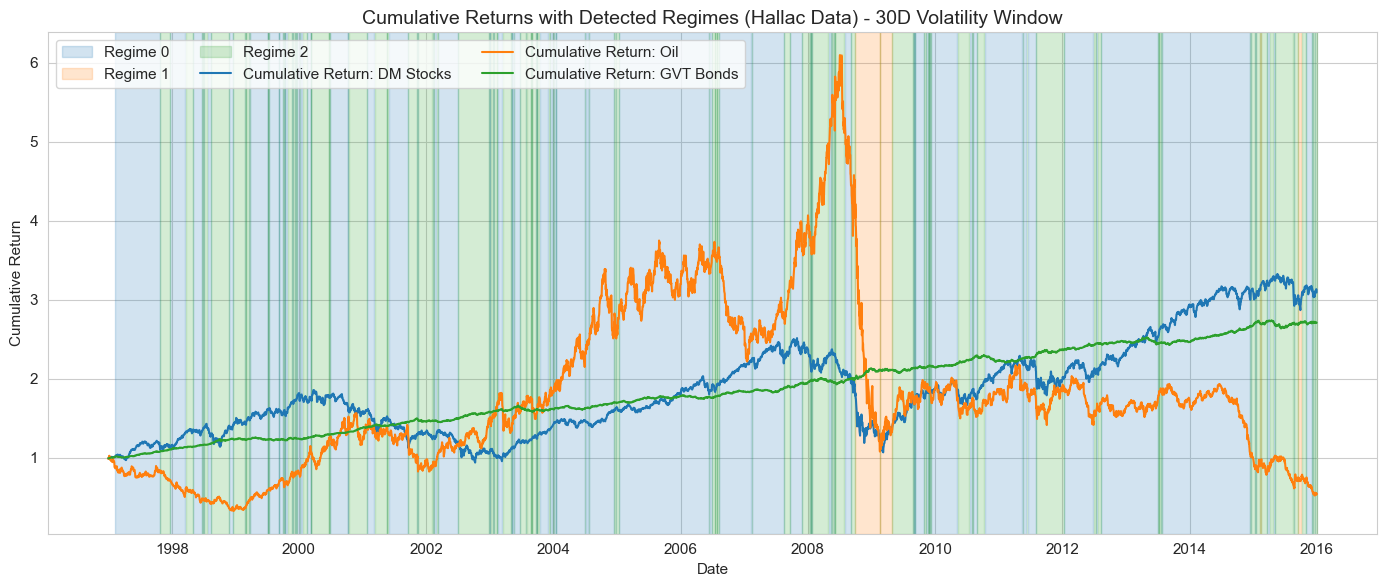

In [36]:
# Test the model with the same 30 day volatilty window I used
best_k = 3
regime_names = [f'Regime {i}' for i in range(best_k)]

hallac_regime_labels_30v_df = run_hallac_gmm_model(vol_window=30, best_k=best_k, regime_names=regime_names)
plot_hallac_regimes(hallac_regime_labels_30v_df, hallac_data)

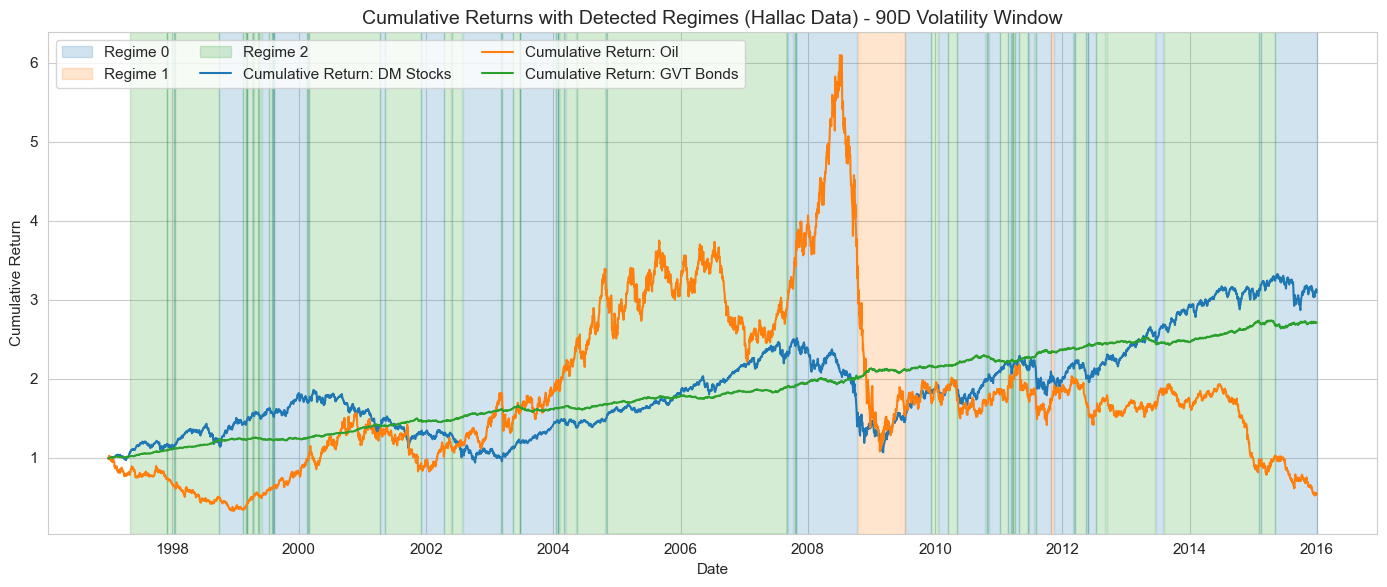

In [37]:
hallac_regime_labels_90v_df = run_hallac_gmm_model(vol_window=90, best_k=best_k, regime_names=regime_names)
plot_hallac_regimes(hallac_regime_labels_90v_df, hallac_data, vol_window=90)


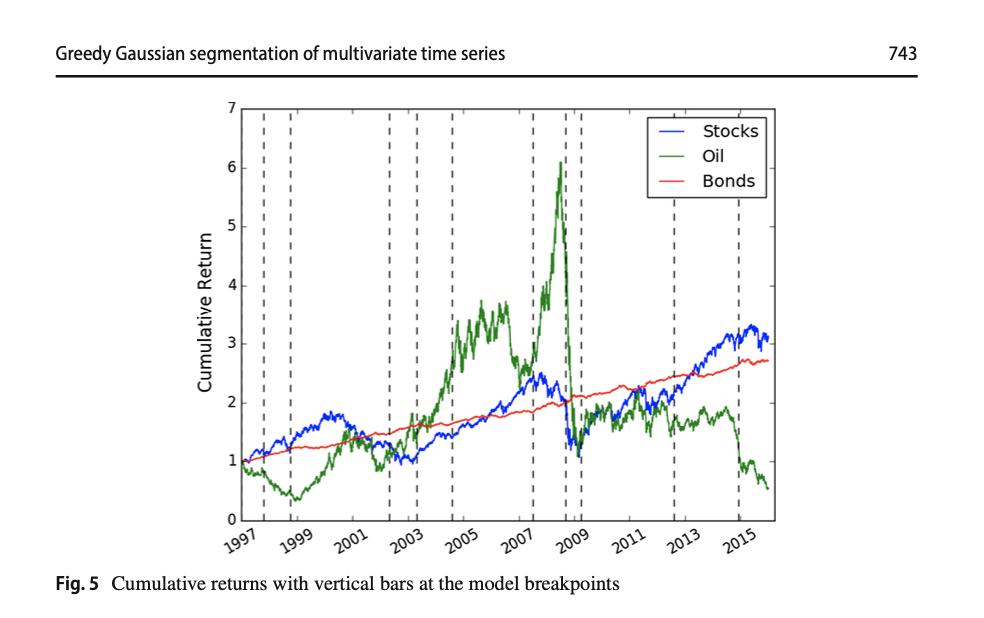

In [38]:
# Compare again to the original paper

from IPython.display import Image
Image(filename='hallac_3tickers_10breakpoints.png')

## References

1. McGreevy, J., et al. (2024). *Detecting Multivariate Market Regimes Via Clustering Algorithms* [http://dx.doi.org/10.2139/ssrn.4758243]
2. Kritzman, Mark and Li, Yuanzhen and Page, Sebastien and Rigobon, Roberto. (2010) *Principal Components as a Measure of Systemic Risk*. [http://dx.doi.org/10.2139/ssrn.1582687]
3. Hallac, D., Nystrup, P. & Boyd, S. (2019). *Greedy Gaussian segmentation of multivariate time series* [https://doi.org/10.1007/s11634-018-0335-0]
4. Cont, R. (2001). Empirical properties of asset returns: stylized facts and statistical issues. Quantitative Finance, 1(2), 223–236. [https://doi.org/10.1080/713665670]
5. Lalou, L., et al. (1998). *Noise Dressing of Financial Correlation Matrices* [https://doi.org/10.48550/arXiv.cond-mat/9810255]
6. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*
7. Schwarz, G. (1978). Estimating the Dimension of a Model. The Annals of Statistics, 6(2), 461–464. [http://www.jstor.org/stable/2958889]

## Appendices

Supplementary functions and visualisations for the identified sections are included here.

### 1. EDA

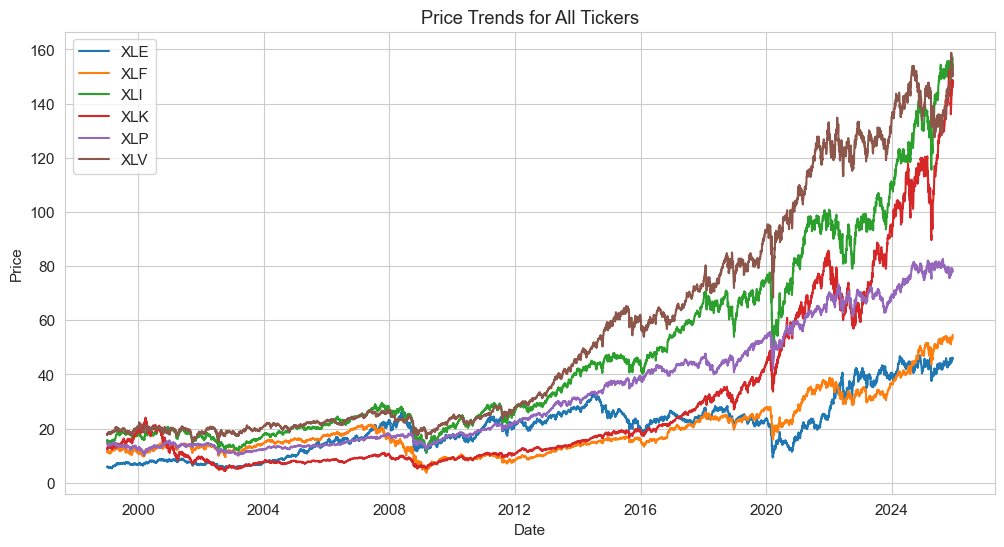

In [ ]:
plot_trends(prices, 'Price')

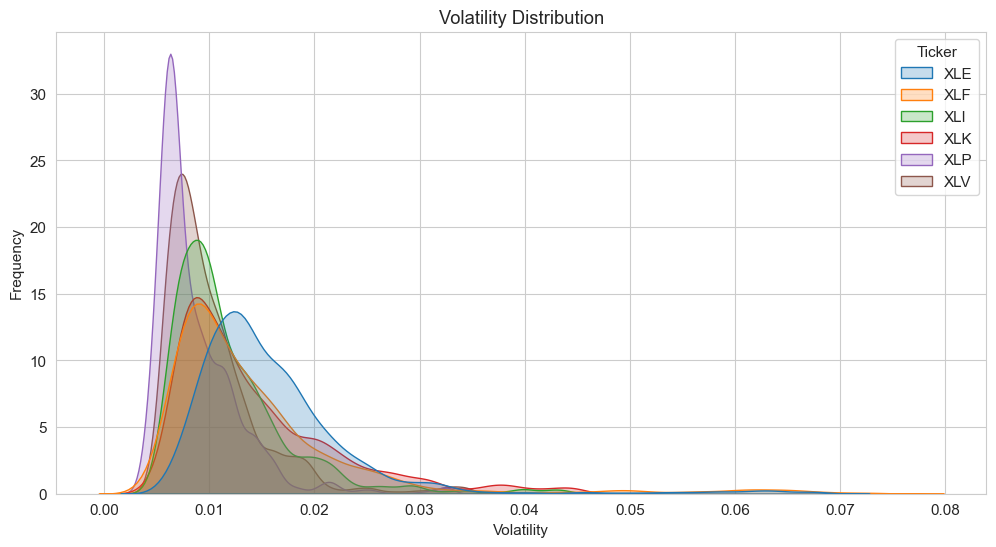

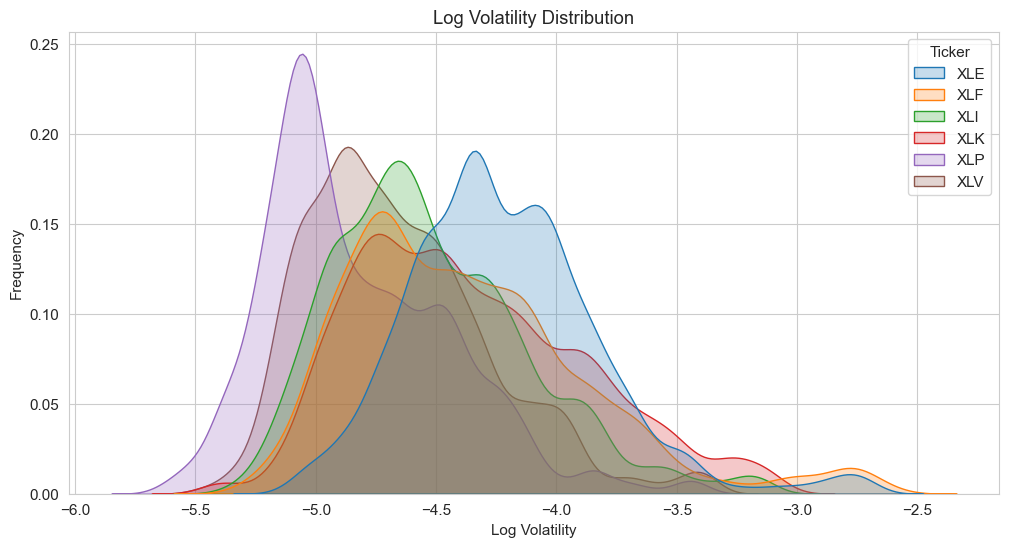

In [40]:
plot_kde(volatility, 'Volatility')
plt.show()
plot_kde(log_vol, 'Log Volatility')

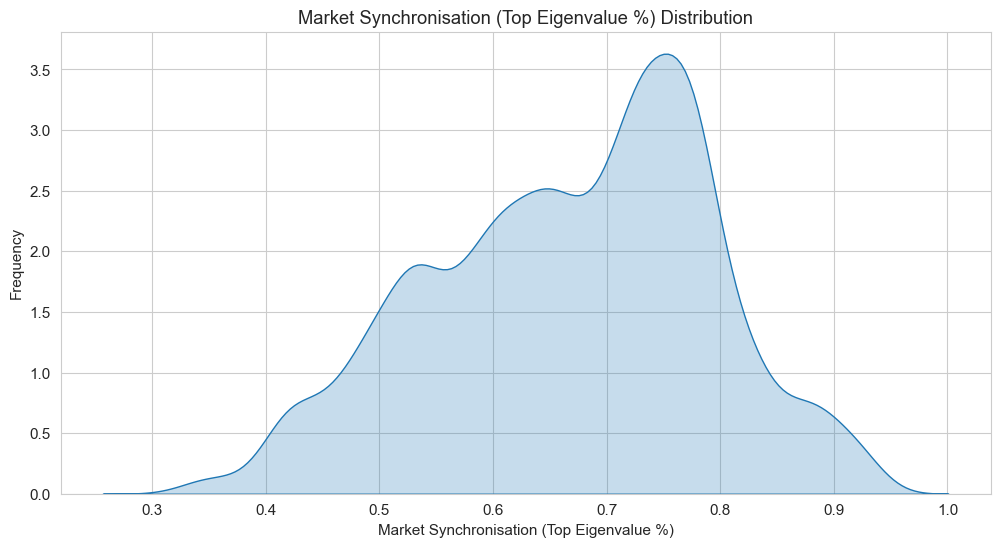

In [41]:
plot_kde(top_eig_proportion, 'Market Synchronisation (Top Eigenvalue %)')

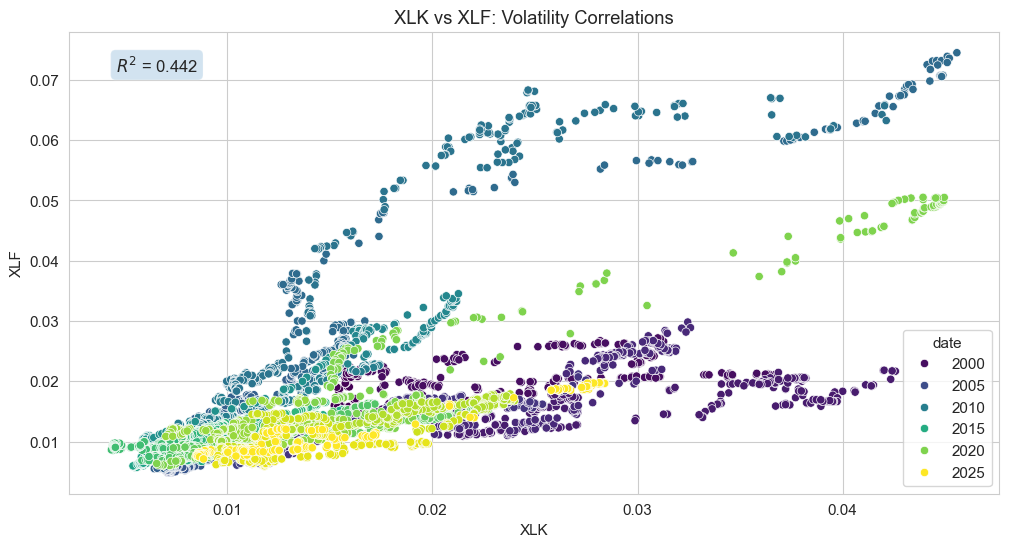

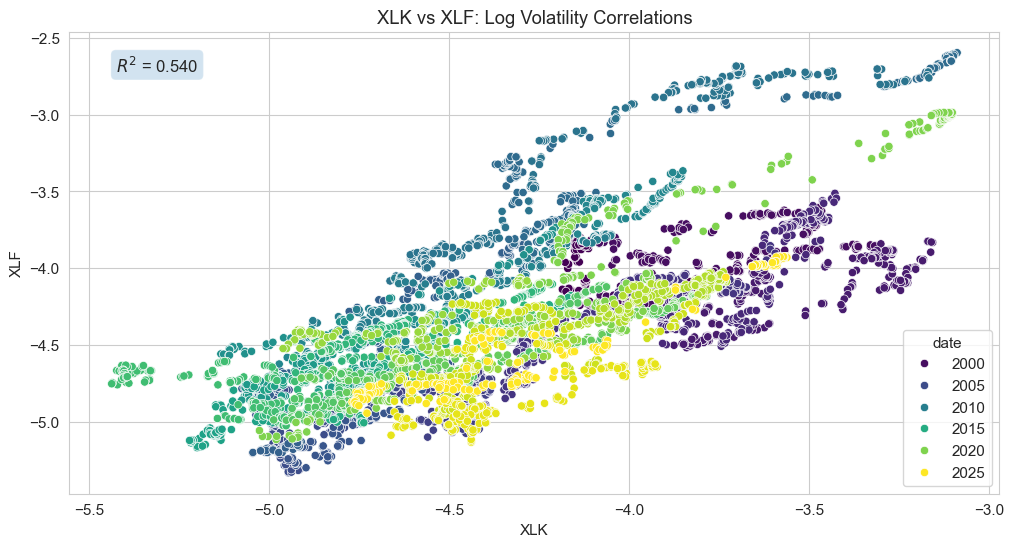

In [42]:
plot_correlations_over_time(volatility, 'Volatility')
plt.show()
plot_correlations_over_time(log_vol, 'Log Volatility')

### 2. Clustering

In [43]:
algo_results = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=40466218, n_init=10)
    km_labels = km.fit_predict(X_final_scaled)
    
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=10, random_state=40466218)
    gmm_labels = gmm.fit_predict(X_final_scaled)
    
    algo_results.append({
        'k': k,
        'KMeans Sil': silhouette_score(X_final_scaled, km_labels),
        'GMM Sil': silhouette_score(X_final_scaled, gmm_labels)
    })

algo_df = pd.DataFrame(algo_results)
print("ALGORITHM COMPARISON: K-Means vs GMM")
print("="*60)
display(algo_df.round(2))

ALGORITHM COMPARISON: K-Means vs GMM


,k,KMeans Sil,GMM Sil
0,2,0.54,0.42
1,3,0.44,0.38
2,4,0.31,0.29
3,5,0.27,0.16
4,6,0.27,0.15


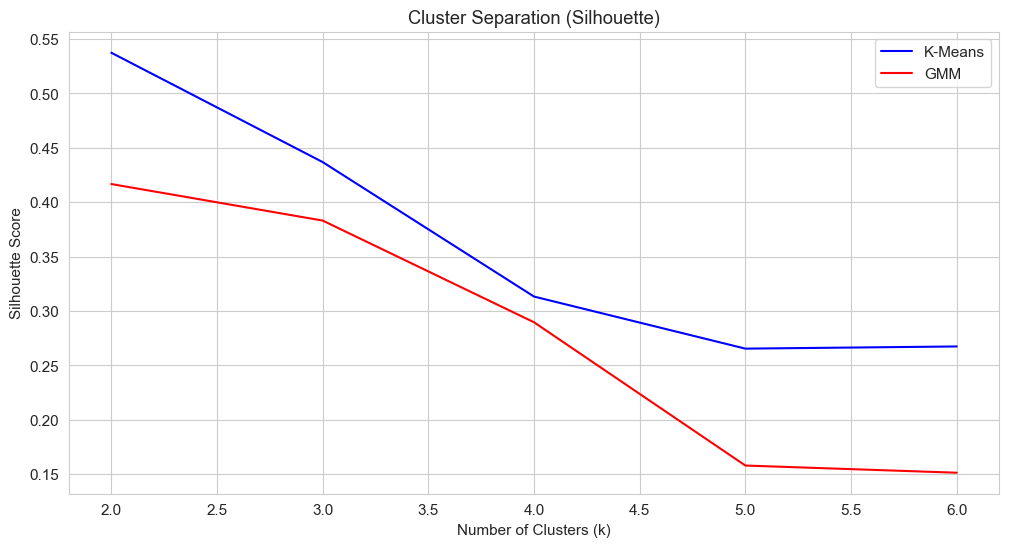

In [44]:
sns.lineplot(x="k", y="KMeans Sil", data=algo_df, label="K-Means", color='blue')
sns.lineplot(x="k", y="GMM Sil", data=algo_df, label="GMM", color='red')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Cluster Separation (Silhouette)');

In [45]:
# Build DataFrame of regime probabilities and assignments
regime_probabilities_df = pd.DataFrame(probs, index=X_final.index, columns=regime_names)

print("Regime Probabilities")
print("="*70)
regime_probabilities_df.round(3)

Regime Probabilities


,Regime 0,Regime 1,Regime 2
date,,,
1999-02-17,1.000,0.000,0.0
1999-02-18,1.000,0.000,0.0
1999-02-19,1.000,0.000,0.0
1999-02-22,1.000,0.000,0.0
1999-02-23,1.000,0.000,0.0
...,...,...,...
2025-12-05,0.009,0.991,0.0
2025-12-08,0.009,0.991,0.0
2025-12-09,0.008,0.992,0.0


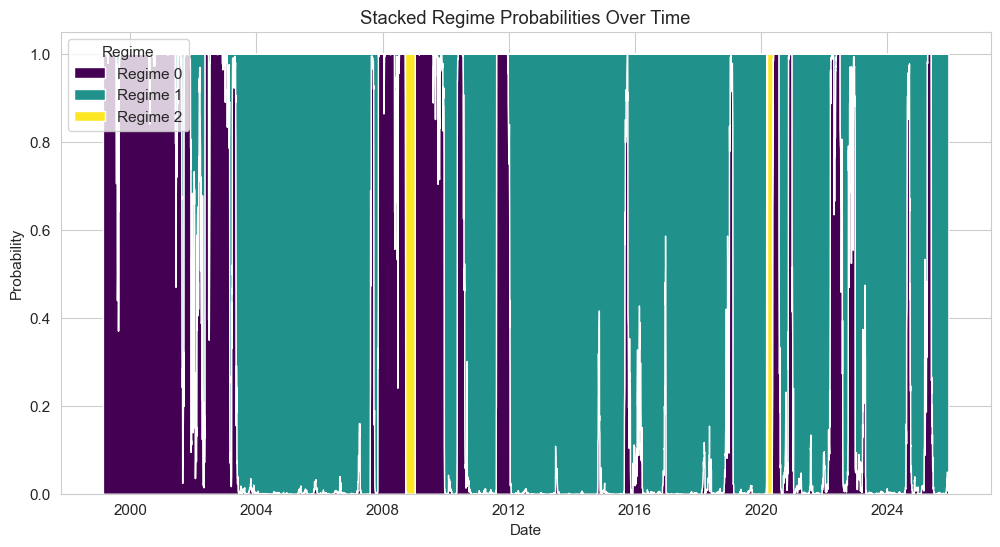

In [46]:
# Plot stacked area chart of regime probabilities over time
plt.stackplot(
    regime_probabilities_df.index, 
    regime_probabilities_df[regime_probabilities_df.columns].T, 
    labels=regime_probabilities_df.columns, 
    colors=plt.cm.viridis(np.linspace(0, 1, len(regime_probabilities_df.columns)))
)
plt.legend(loc='upper left', title='Regime')
plt.title("Stacked Regime Probabilities Over Time")
plt.xlabel("Date")
plt.ylabel("Probability");
plt.show()

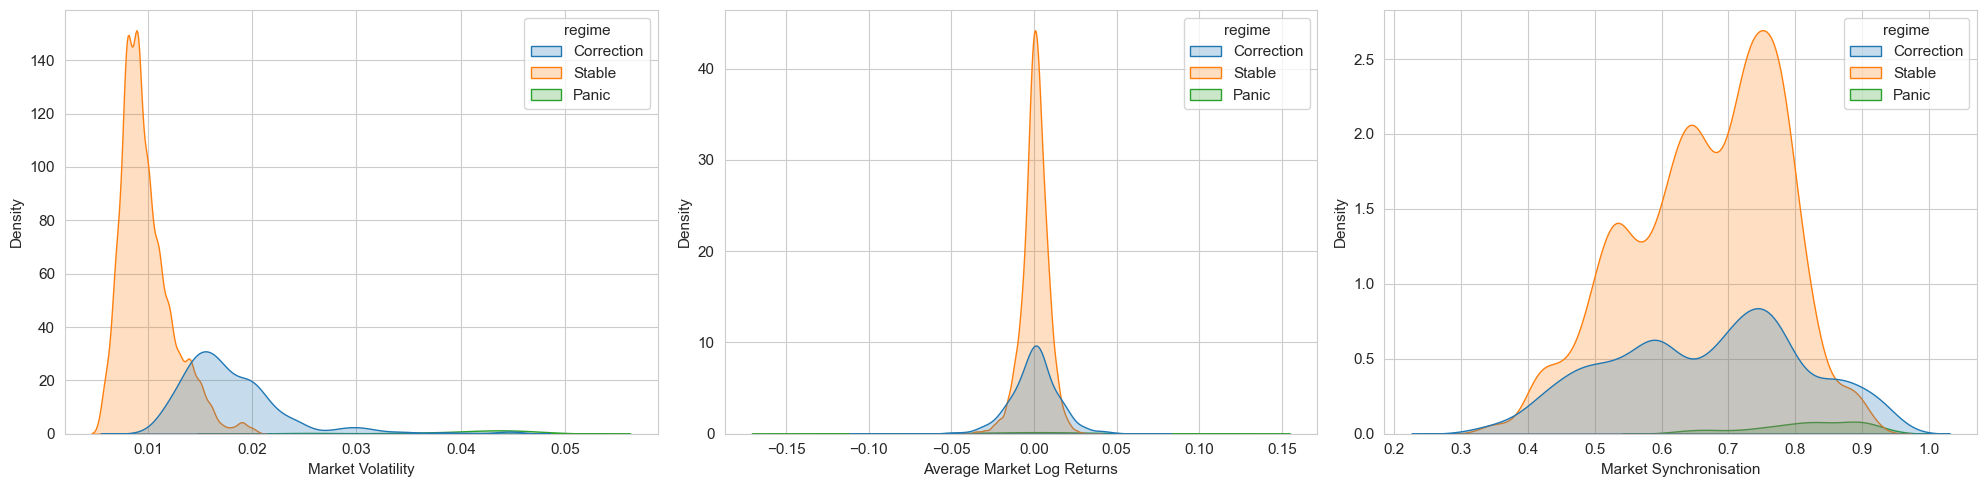

In [47]:
# Compute summary market statistics
market_stats = pd.DataFrame({
    'Market Volatility': volatility.mean(axis=1),
    'Average Market Log Returns': log_returns.mean(axis=1),
    'Market Synchronisation': eigvals_over_time(log_returns)
})

# Create regime profiles dataframe with summary statistics
regime_profiles = regime_labels_df.join(market_stats, how='inner').round(3)

# Plot the volatility, average market log returns, and market synchronisation by regime
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.kdeplot(regime_profiles, x='Market Volatility', hue='regime', ax=axes[0], fill=True)
sns.kdeplot(regime_profiles, x='Average Market Log Returns', hue='regime', ax=axes[1], fill=True)
sns.kdeplot(regime_profiles, x='Market Synchronisation', hue='regime', ax=axes[2], fill=True);
plt.tight_layout();

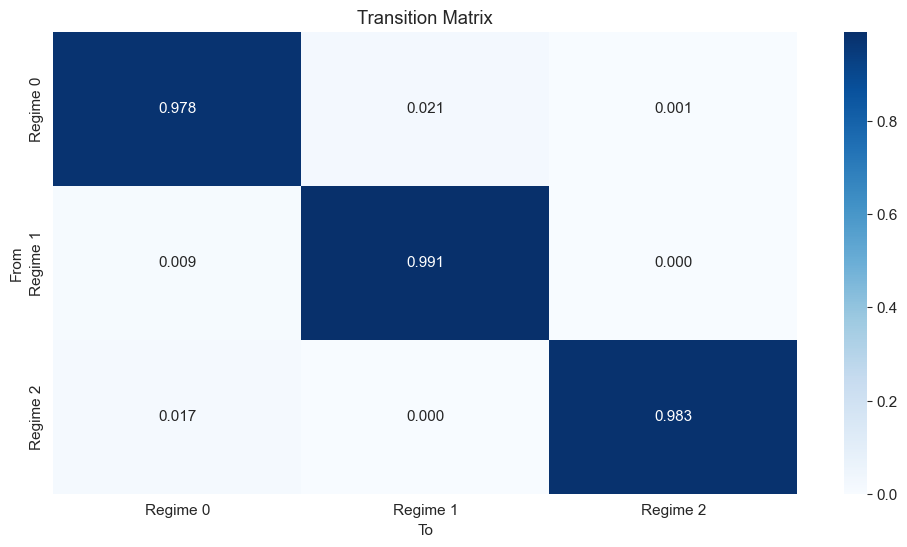

In [48]:
# Display the transition matrix (probability of transitioning from one regime to another)
transition_to = labels[1:]
transition_from = labels[:-1]
trans_mat = pd.crosstab(transition_from, transition_to, normalize='index').reindex(
    index=range(best_k), columns=range(best_k), fill_value=0
)

sns.heatmap(trans_mat, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=[f'{regime_names[i]}' for i in range(3)],
            yticklabels=[f'{regime_names[i]}' for i in range(3)])
plt.title('Transition Matrix'); plt.ylabel('From'); plt.xlabel('To');